# Best practices for your confirmatory factor analysis

A JASP and lavaan tutorial

Pablo Rogers [](https://orcid.org/0000-0002-0093-3834) (Universidade Federal de Uberlândia)  
March 13, 2024

This supplementary material provides the complete R/lavaan implementation for the confirmatory factor analysis (CFA) tutorial presented in @rogers2024. The analyses use the WHOQOL-BREF instrument — a 24-item quality of life measure covering four domains: Psychological, Physical, Social, and Environment — with data from a Brazilian sample of 1,047 respondents \[@rogers2021\]. The codes that generates the outputs for this tutorial article can be found in the notebook: <https://phdpablo.github.io/cfa-brm/index-preview.html>

## Introduction

A central challenge in applied CFA is that items are typically measured on ordinal Likert scales, yet many textbooks and software default to Maximum Likelihood (ML) estimation, which assumes continuous, multivariate normal data. As discussed in @rogers2024, the appropriate approach for ordinal data is the Diagonally Weighted Least Squares (DWLS) estimator — implemented as WLSMV in lavaan — which operates on polychoric correlations rather than Pearson correlations and does not assume normality of observed variables.

> **Tutorial Structure**
>
> This document is organized as a manuscript project: the **Article** presents the analytical narrative and results without showing code, while the **Article Notebook** displays the full R code behind every result. Both views share the same content — the only difference is code visibility.

## Setup

We begin by loading all required R packages. The `lavaan` package provides the core CFA estimation engine; `semTools` extends it with reliability functions and additional diagnostics; `semPlot` produces path diagrams; `psych` provides descriptive statistics and omega coefficients for bifactor models; `simsem` enables Monte Carlo simulation for power analysis; and `dynamic` computes the Dynamic Fit Index (DFI) cutoffs.

In [ ]:
library(lavaan)
library(semTools)
library(semPlot)
library(psych)
library(simsem)
library(MASS)
library(dynamic)
library(dplyr)
library(ggplot2)

We set global options and a seed for reproducibility. The seed ensures that all simulation-based results (power analysis) are exactly reproducible.

In [ ]:
options(max.print = 1000000)
set.seed(123456)

> **A Note on Code Design**
>
> Throughout this tutorial, you will notice that some code patterns are repeated across sections — for example, extracting fit indices, formatting factor loadings, and building comparison tables. In a production environment, these routines would typically be modularized into reusable R functions and sourced from separate scripts.
>
> We deliberately chose **not** to do this. Each analysis section is self-contained, with all code written explicitly and in sequence. This design sacrifices automation and conciseness in favor of **transparency**: the reader can follow each step without navigating between files or tracing function definitions. For a tutorial whose primary goal is to teach CFA best practices, we believe clarity of exposition is more valuable than code elegance.
>
> Readers who wish to adapt this workflow for their own research are encouraged to refactor repeated patterns into functions and organize them into modular scripts — this is, in fact, a best practice for reproducible research projects.

## Step 1: ETL — Extract, Transform, Load

The WHOQOL-BREF dataset is loaded directly from the Mendeley Data repository \[@rogers2021\]. The data file contains N = 1,047 observations with 24 items. A separate label file provides the variable names following the naming convention: item number followed by a suffix indicating its domain (\_P = Psychological, \_F = Physical, \_S = Social, \_A = Environment). Items Q3, Q4, and Q26 have already been reverse-coded in the source data so that higher values consistently indicate better quality of life.

In [ ]:
url_data <- "https://data.mendeley.com/datasets/rdky78bk8r/2/files/b58a7054-4978-4239-81db-00f9efd86e44/WHOQOL_Data.dat"
df0 <- read.table(url_data)

url_labels <- "https://data.mendeley.com/datasets/rdky78bk8r/2/files/ae2a5c01-2fc2-43e5-b31c-8db8cc5bff8a/WHOQOL_Labels.txt"
column_labels <- read.table(url_labels)
column_labels <- column_labels$V1
names(df0) <- column_labels

@tbl-data-head shows the first six observations (n). All variables are integer-coded (1–5), reflecting the five-point Likert response format.

In [ ]:
df_head <- head(df0)
df_t <- as.data.frame(t(df_head))
colnames(df_t) <- paste0("n", seq_len(ncol(df_t)))
knitr::kable(df_t)

            n1   n2   n3   n4   n5   n6
  ------- ---- ---- ---- ---- ---- ----
  Q3_F       5    5    5    5    3    2
  Q4_F       4    5    4    5    4    4
  Q10_F      2    3    3    5    3    4
  Q15_F      5    3    4    5    4    4
  Q16_F      3    3    5    5    4    4
  Q17_F      4    3    2    4    4    4
  Q18_F      3    2    2    5    4    4
  Q5_P       3    3    4    4    3    3
  Q6_P       3    2    4    5    5    4
  Q7_P       2    2    2    5    3    3
  Q11_P      2    3    4    5    2    4
  Q19_P      2    3    3    4    4    4
  Q26_P      4    4    2    5    4    4
  Q20_S      4    2    4    4    4    4
  Q21_S      2    3    5    5    5    2
  Q22_S      2    2    5    5    4    4
  Q8_A       4    3    3    4    2    3
  Q9_A       3    2    2    4    2    3
  Q12_A      3    2    3    5    3    2
  Q13_A      4    2    4    5    3    4
  Q14_A      3    3    3    4    2    3
  Q23_A      2    2    5    5    5    4
  Q24_A      2    4    5    3    3    2
  Q25_A      2    2    5    5    3    4


@tbl-descriptives presents the descriptive statistics for all 24 items. Means range from approximately 3.0 to 4.0, with standard deviations around 0.8–1.1, indicating moderate variability across items. No floor or ceiling effects are evident, and skewness values are generally within acceptable bounds (\|sk\| \< 1), supporting the use of polychoric correlations. These statistics are consistent with the original validation study \[@rogers2024\].

In [ ]:
knitr::kable(describe(df0), digits = 2)

  -----------------------------------------------------------------------------------------------------------
            vars      n   mean     sd   median   trimmed    mad   min   max   range    skew   kurtosis     se
  ------- ------ ------ ------ ------ -------- --------- ------ ----- ----- ------- ------- ---------- ------
  Q3_F         1   1047   4.17   0.93        4      4.31   1.48     1     5       4   -0.99       0.27   0.03

  Q4_F         2   1047   4.10   1.01        4      4.26   1.48     1     5       4   -1.02       0.31   0.03

  Q10_F        3   1047   3.61   0.91        4      3.65   1.48     1     5       4   -0.18      -0.43   0.03

  Q15_F        4   1047   4.42   0.79        5      4.57   0.00     1     5       4   -1.52       2.41   0.02

  Q16_F        5   1047   3.50   1.03        4      3.49   1.48     2     5       3   -0.13      -1.16   0.03

  Q17_F        6   1047   3.72   0.92        4      3.78   0.00     2     5       3   -0.51      -0.53   0.03

  Q18_F        7   1047   3.75   0.96        4      3.81   1.48     2     5       3   -0.50      -0.64   0.03

  Q5_P         8   1047   3.29   0.82        3      3.35   1.48     1     5       4   -0.44      -0.09   0.03

  Q6_P         9   1047   3.90   0.99        4      4.02   1.48     1     5       4   -0.88       0.48   0.03

  Q7_P        10   1047   3.61   0.86        4      3.66   1.48     1     5       4   -0.53       0.12   0.03

  Q11_P       11   1047   3.82   0.99        4      3.92   1.48     1     5       4   -0.62      -0.09   0.03

  Q19_P       12   1047   3.72   0.95        4      3.77   1.48     2     5       3   -0.42      -0.70   0.03

  Q26_P       13   1047   3.91   0.92        4      4.03   0.00     1     5       4   -1.19       1.68   0.03

  Q20_S       14   1047   3.64   0.89        4      3.67   1.48     2     5       3   -0.25      -0.66   0.03

  Q21_S       15   1047   3.46   1.00        4      3.45   1.48     2     5       3   -0.05      -1.09   0.03

  Q22_S       16   1047   3.58   0.88        4      3.60   1.48     2     5       3   -0.16      -0.69   0.03

  Q8_A        17   1047   2.94   0.98        3      2.97   1.48     1     5       4   -0.11      -0.43   0.03

  Q9_A        18   1047   3.47   0.91        4      3.52   1.48     1     5       4   -0.64       0.26   0.03

  Q12_A       19   1047   3.45   1.10        3      3.50   1.48     1     5       4   -0.25      -0.54   0.03

  Q13_A       20   1047   3.93   0.82        4      3.98   1.48     1     5       4   -0.57       0.15   0.03

  Q14_A       21   1047   3.34   0.96        3      3.34   1.48     1     5       4   -0.29      -0.26   0.03

  Q23_A       22   1047   3.98   0.97        4      4.09   1.48     2     5       3   -0.70      -0.45   0.03

  Q24_A       23   1047   3.73   0.97        4      3.79   1.48     2     5       3   -0.40      -0.79   0.03

  Q25_A       24   1047   3.83   0.98        4      3.91   1.48     2     5       3   -0.50      -0.72   0.03
  -----------------------------------------------------------------------------------------------------------


> **Data Overview**
>
> The dataset contains N = 1047 observations on 24 variables. All items are measured on a 5-point Likert scale (1–5), representing ordinal data. This ordinal nature is fundamental: it requires the use of polychoric correlations and DWLS estimation rather than Pearson correlations and ML.

## Population Model

Before fitting CFA models to our sample data, we define a *population model* that serves two purposes: (1) computing Dynamic Fit Index (DFI) cutoffs tailored to this specific model structure and sample size, and (2) conducting *a priori* power analysis via simulation.

The population model is based on the meta-analytic factor loadings from @lin2022, who validated the WHOQOL-BREF factor structure using a meta-analysis of exploratory factor analyses combined with social network analysis. Factor correlations were set at 0.3, reflecting the upper bound reported in @lin2022 (range 0.08–0.30). Residual variances were derived analytically as 1 − λ² (except for Q3 and Q4, whose residuals are adjusted for their predicted correlation).

Given the ordinal nature of the variables, we assume equidistant thresholds following a linearity assumption with proportions of approximately 12%, 23%, 31%, 23%, and 12%. For a five-point Likert scale, this translates to threshold values of −1.2, −0.4, 0.4, and 1.2. While it is unlikely that thresholds from previous studies will be available, if response frequencies per category per item are provided, thresholds can be estimated using the inverse normal distribution.

> **Important Caveat**
>
> This population model should be understood as a **teaching illustration**. The loadings from @lin2022 come primarily from exploratory factor analysis studies using principal components with varimax rotation — a method that has well-known limitations \[@rogers2022\]. Ideally, one should seek a robust national survey that has employed CFA with ordinal data for the WHOQOL-BREF, providing more appropriate starting values.

In [ ]:
pop_model <- "
 # Define factors and set loadings according to Lin and Yao (2022)
psycho =~ 0.92*Q5_P + 0.81*Q6_P + 0.94*Q7_P + 0.73*Q11_P + 0.75*Q19_P + 0.63*Q26_P
physical =~ 0.84*Q3_F + 0.83*Q4_F + 0.63*Q10_F + 0.71*Q15_F + 0.68*Q16_F
            + 0.89*Q17_F + 0.61*Q18_F
social =~ 0.94*Q20_S + 0.89*Q21_S + 0.78*Q22_S
environment =~ 0.37*Q8_A + 0.49*Q9_A + 0.79*Q12_A + 0.81*Q13_A + 0.77*Q14_A
               + 0.75*Q23_A + 0.64*Q24_A + 0.73*Q25_A
 # Set the maximum acceptable correlation between Q4 and Q3
Q4_F ~~ 0.3*Q3_F
 # Set factor variances to 1 and correlations to 0.3
psycho ~~ 1*psycho + 0.3*physical + 0.3*social + 0.3*environment
physical ~~ 1*physical + 0.3*social + 0.3*environment
social ~~ 1*social + 0.3*environment
environment ~~ 1*environment
 # Set all item residual variances according to defined loadings (1-L^2)
 # Except Q3 and Q4 due to the predicted correlation between the two
Q5_P ~~ 0.15*Q5_P
Q6_P ~~ 0.34*Q6_P
Q7_P ~~ 0.12*Q7_P
Q11_P ~~ 0.47*Q11_P
Q19_P ~~ 0.44*Q19_P
Q26_P ~~ 0.6*Q26_P
Q10_F ~~ 0.6*Q10_F
Q15_F ~~ 0.5*Q15_F
Q16_F ~~ 0.54*Q16_F
Q17_F ~~ 0.21*Q17_F
Q18_F ~~ 0.63*Q18_F
Q20_S ~~ 0.12*Q20_S
Q21_S ~~ 0.21*Q21_S
Q22_S ~~ 0.39*Q22_S
Q8_A ~~ 0.86*Q8_A
Q9_A ~~ 0.76*Q9_A
Q12_A ~~ 0.38*Q12_A
Q13_A ~~ 0.34*Q13_A
Q14_A ~~ 0.41*Q14_A
Q23_A ~~ 0.44*Q23_A
Q24_A ~~ 0.59*Q24_A
Q25_A ~~ 0.47*Q25_A
 # Set equidistant thresholds for all items
Q5_P | -1.2*t1
Q5_P | -0.4*t2
Q5_P | 0.4*t3
Q5_P | 1.2*t4
Q6_P | -1.2*t1
Q6_P | -0.4*t2
Q6_P | 0.4*t3
Q6_P | 1.2*t4
Q7_P | -1.2*t1
Q7_P | -0.4*t2
Q7_P | 0.4*t3
Q7_P | 1.2*t4
Q11_P | -1.2*t1
Q11_P | -0.4*t2
Q11_P | 0.4*t3
Q11_P | 1.2*t4
Q19_P | -1.2*t1
Q19_P | -0.4*t2
Q19_P | 0.4*t3
Q19_P | 1.2*t4
Q26_P | -1.2*t1
Q26_P | -0.4*t2
Q26_P | 0.4*t3
Q26_P | 1.2*t4
Q3_F | -1.2*t1
Q3_F | -0.4*t2
Q3_F | 0.4*t3
Q3_F | 1.2*t4
Q4_F | -1.2*t1
Q4_F | -0.4*t2
Q4_F | 0.4*t3
Q4_F | 1.2*t4
Q10_F | -1.2*t1
Q10_F | -0.4*t2
Q10_F | 0.4*t3
Q10_F | 1.2*t4
Q15_F | -1.2*t1
Q15_F | -0.4*t2
Q15_F | 0.4*t3
Q15_F | 1.2*t4
Q16_F | -1.2*t1
Q16_F | -0.4*t2
Q16_F | 0.4*t3
Q16_F | 1.2*t4
Q17_F | -1.2*t1
Q17_F | -0.4*t2
Q17_F | 0.4*t3
Q17_F | 1.2*t4
Q18_F | -1.2*t1
Q18_F | -0.4*t2
Q18_F | 0.4*t3
Q18_F | 1.2*t4
Q20_S | -1.2*t1
Q20_S | -0.4*t2
Q20_S | 0.4*t3
Q20_S | 1.2*t4
Q21_S | -1.2*t1
Q21_S | -0.4*t2
Q21_S | 0.4*t3
Q21_S | 1.2*t4
Q22_S | -1.2*t1
Q22_S | -0.4*t2
Q22_S | 0.4*t3
Q22_S | 1.2*t4
Q8_A | -1.2*t1
Q8_A | -0.4*t2
Q8_A | 0.4*t3
Q8_A | 1.2*t4
Q9_A | -1.2*t1
Q9_A | -0.4*t2
Q9_A | 0.4*t3
Q9_A | 1.2*t4
Q12_A | -1.2*t1
Q12_A | -0.4*t2
Q12_A | 0.4*t3
Q12_A | 1.2*t4
Q13_A | -1.2*t1
Q13_A | -0.4*t2
Q13_A | 0.4*t3
Q13_A | 1.2*t4
Q14_A | -1.2*t1
Q14_A | -0.4*t2
Q14_A | 0.4*t3
Q14_A | 1.2*t4
Q23_A | -1.2*t1
Q23_A | -0.4*t2
Q23_A | 0.4*t3
Q23_A | 1.2*t4
Q24_A | -1.2*t1
Q24_A | -0.4*t2
Q24_A | 0.4*t3
Q24_A | 1.2*t4
Q25_A | -1.2*t1
Q25_A | -0.4*t2
Q25_A | 0.4*t3
Q25_A | 1.2*t4
"

### Dynamic Fit Index (DFI)

The Dynamic Fit Index \[@mcneish2023likert\] provides simulation-based cutoff values for fit indices that are tailored to a specific model structure and sample size, rather than relying on generic rules of thumb (e.g., CFI \> .95, RMSEA \< .06). The DFI computation requires the population model defined above.

   variances of ordered variables are ignored when parameterization = 
   "delta"; please remove them from the model syntax or use parameterization 
   = "theta"; variables involved are: Q5_P Q6_P Q7_P Q11_P Q19_P Q26_P Q10_F 
   Q15_F Q16_F Q17_F Q18_F Q20_S Q21_S Q22_S Q8_A Q9_A Q12_A Q13_A Q14_A 
   Q23_A Q24_A Q25_A
   variances of ordered variables are ignored when parameterization = 
   "delta"; please remove them from the model syntax or use parameterization 
   = "theta"; variables involved are: Q5_P Q6_P Q7_P Q11_P Q19_P Q26_P Q10_F 
   Q15_F Q16_F Q17_F Q18_F Q20_S Q21_S Q22_S Q8_A Q9_A Q12_A Q13_A Q14_A 
   Q23_A Q24_A Q25_A
   variances of ordered variables are ignored when parameterization = 
   "delta"; please remove them from the model syntax or use parameterization 
   = "theta"; variables involved are: Q5_P Q6_P Q7_P Q11_P Q19_P Q26_P Q10_F 
   Q15_F Q16_F Q17_F Q18_F Q20_S Q21_S Q22_S Q8_A Q9_A Q12_A Q13_A Q14_A 
   Q23_A Q24_A Q25_A

ℹ Please use `linewidth` instead.
ℹ The deprecated feature was likely used in the dynamic package.
  Please report the issue at <https://github.com/melissagwolf/dynamic/issues>.

Your DFI cutoffs: 
            SRMR  RMSEA CFI   Magnitude
Level-0     0.024 0.012 0.998 NONE     
Specificity 95%   95%   95%            
                                       
Level-1     0.038 0.037 0.985 0.37     
Sensitivity 95%   95%   95%            
                                       
Level-2     0.064 0.083 0.934 0.599    
Sensitivity 95%   95%   95%            
                                       
Level-3     0.078 0.105 0.904 0.58     
Sensitivity 95%   95%   95%            

 Notes:
  -Number of levels is based on the number of factors in the model
  -'Sensitivity' is % of hypothetically misspecified models correctly identified by cutoff in DFI simulation
  -Cutoffs with 95% sensitivity are reported when possible
  -If sensitivity is <50%, cutoffs will be supressed 

 The distributions for each level are in the Plots tab 
[[1]]

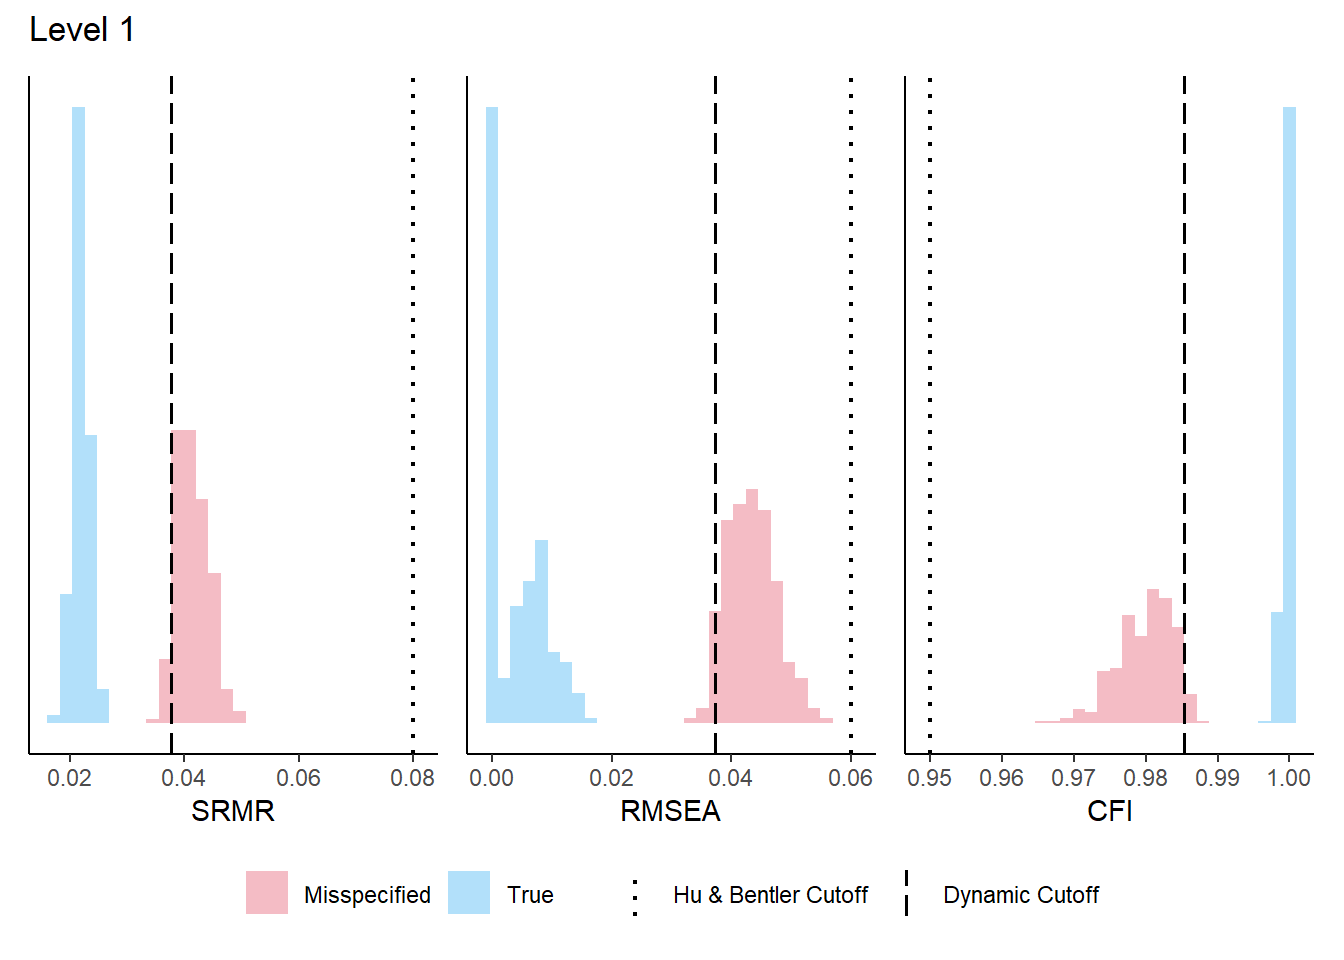


[[2]]

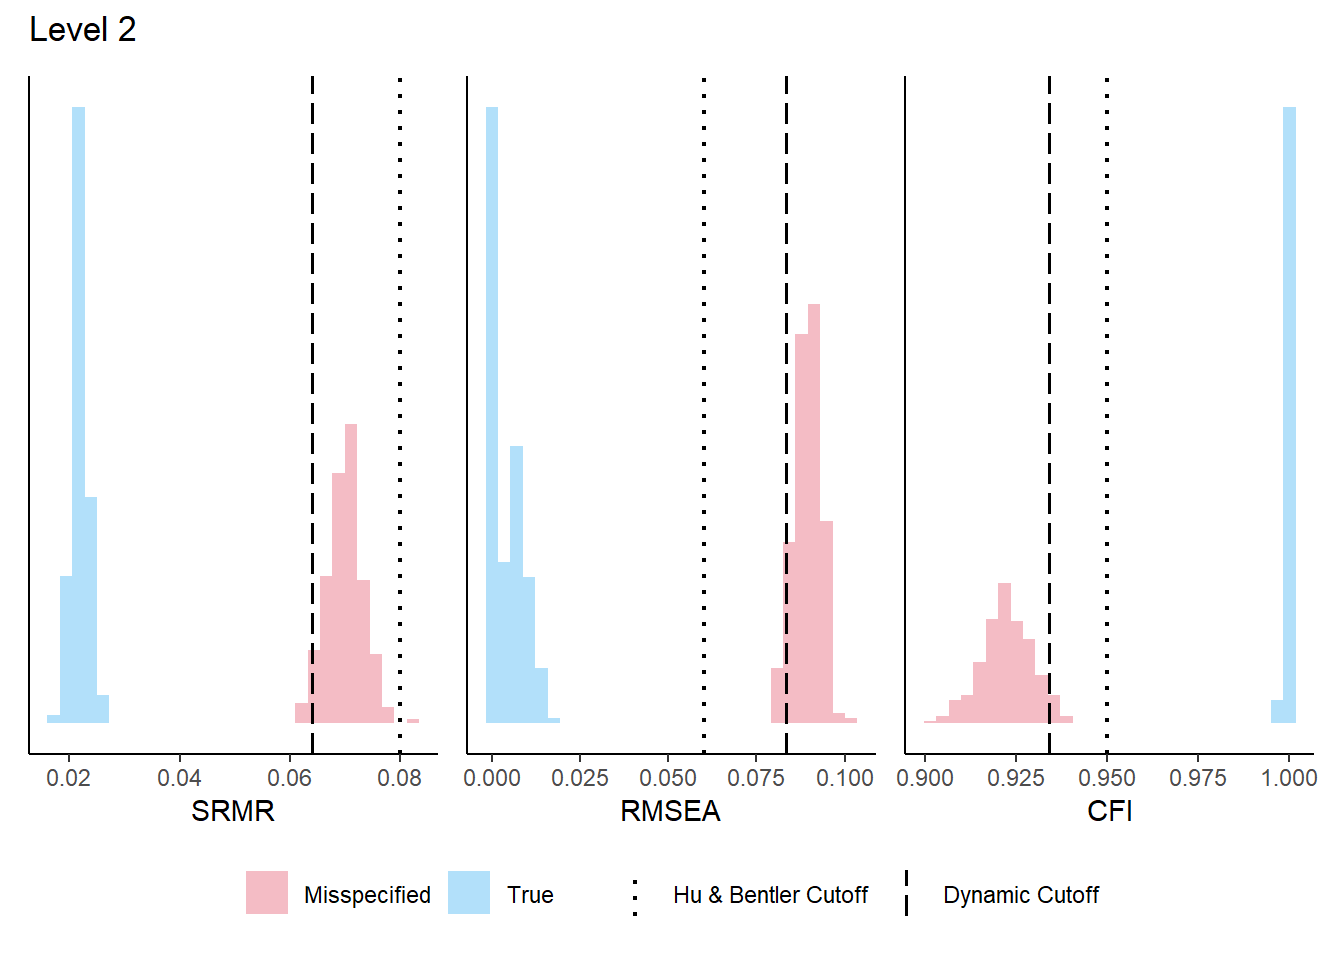


[[3]]

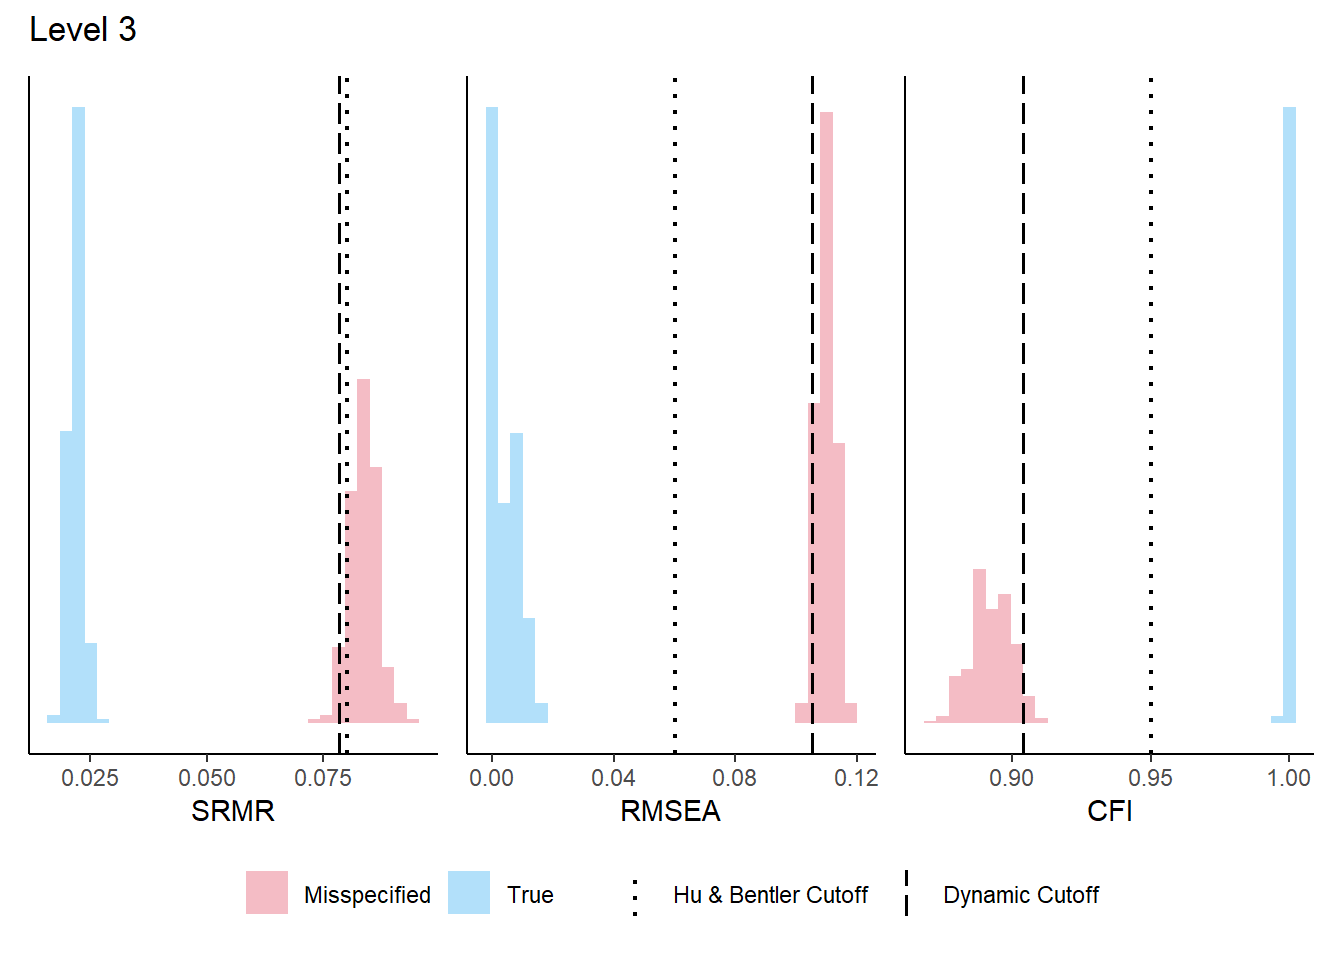

In [ ]:
dynamic::catHB(pop_model, manual = TRUE, n = 1047, plot = TRUE)

Note that we could compute a separate DFI for each estimated model (assuming each in turn as the population model). However, this would sacrifice comparability across models. Moreover, DFI methods for bifactor models are not yet available, and those for hierarchical models are still in development.

## 4-Factor CFA Model

The first model tested is the standard four correlated factor model, which represents the theoretical structure of the WHOQOL-BREF \[@lin2022\].

### Model Specification

Each of the 24 items loads on exactly one of the four latent factors: Psychological (6 items), Physical (7 items), Social (3 items), and Environment (8 items). Latent factors are allowed to freely correlate, reflecting the expected interrelations among quality of life domains. A residual covariance between items Q3 and Q4 is included based on prior theoretical and empirical evidence, as both items assess related aspects within the Physical domain.

In [ ]:
spe_4fa <- "
psycho =~ Q5_P + Q6_P + Q7_P + Q11_P + Q19_P + Q26_P
physical =~ Q3_F + Q4_F + Q10_F + Q15_F + Q16_F + Q17_F + Q18_F
social =~ Q20_S + Q21_S + Q22_S
environment =~ Q8_A + Q9_A + Q12_A + Q13_A + Q14_A + Q23_A + Q24_A + Q25_A
Q4_F ~~ Q3_F
"

### Model Estimation

The estimation uses DWLS (WLSMV in lavaan) with all items declared as ordinal (`ordered = TRUE`), and factor variances are fixed to 1 (`std.lv = TRUE`) for identification.

In [ ]:
est_4fa <- cfa(
  spe_4fa,
  data = df0,
  ordered = TRUE,
  std.lv = TRUE,
  estimator = "WLSMV"
)

### Model Evaluation

> **How to Read CFA Output**
>
> When evaluating a CFA model, watch for: (1) **Heywood cases** — standardized loadings \> 1 or negative variance estimates, which indicate estimation problems; (2) **Overall fit** — SRMR \< .08, RMSEA \< .06, CFI/TLI \> .95 using the scaled versions for WLSMV (For reference only, as the correct approach would be to use the cutoffs derived from the DFI); (3) **Local fit** — standardized residuals \> \|2\|, and modification indices (MI) \> 3.84; (4) **Reliability** — GLB and composite reliability (omega) should exceed .70 for adequate internal consistency.

In [ ]:
fit_names <- c("chisq.scaled", "df.scaled", "pvalue.scaled",
               "cfi.scaled", "tli.scaled",
               "rmsea.scaled", "rmsea.ci.lower.scaled", "rmsea.ci.upper.scaled",
               "srmr")
fi <- fitmeasures(est_4fa, fit_names)

fit_df <- data.frame(
  `χ²`     = round(fi["chisq.scaled"], 2),
  df       = fi["df.scaled"],
  p        = round(fi["pvalue.scaled"], 3),
  CFI      = round(fi["cfi.scaled"], 3),
  TLI      = round(fi["tli.scaled"], 3),
  RMSEA    = round(fi["rmsea.scaled"], 3),
  `RMSEA 90% CI` = paste0("[", round(fi["rmsea.ci.lower.scaled"], 3),
                           ", ", round(fi["rmsea.ci.upper.scaled"], 3), "]"),
  SRMR     = round(fi["srmr"], 3),
  check.names = FALSE
)
rownames(fit_df) <- NULL
knitr::kable(fit_df)

         χ²    df   p     CFI     TLI   RMSEA RMSEA 90% CI         SRMR
  --------- ----- --- ------- ------- ------- ----------------- -------
    1732.82   245   0   0.941   0.934   0.076 \[0.073, 0.08\]     0.057


In [ ]:
params <- standardizedSolution(est_4fa)
loadings <- params[params$op == "=~",
                   c("lhs", "rhs", "est.std", "se", "pvalue")]
names(loadings) <- c("Factor", "Item", "Std.Loading", "SE", "p")
loadings$Std.Loading <- round(loadings$Std.Loading, 3)
loadings$SE <- round(loadings$SE, 3)
loadings$p <- ifelse(loadings$p < 0.001, "< .001",
                     round(loadings$p, 3))
rownames(loadings) <- NULL
knitr::kable(loadings)

  Factor        Item      Std.Loading      SE p
  ------------- ------- ------------- ------- ---------
  psycho        Q5_P            0.740   0.017 \< .001
  psycho        Q6_P            0.670   0.018 \< .001
  psycho        Q7_P            0.664   0.018 \< .001
  psycho        Q11_P           0.659   0.020 \< .001
  psycho        Q19_P           0.860   0.012 \< .001
  psycho        Q26_P           0.640   0.020 \< .001
  physical      Q3_F            0.508   0.026 \< .001
  physical      Q4_F            0.423   0.029 \< .001
  physical      Q10_F           0.817   0.012 \< .001
  physical      Q15_F           0.639   0.025 \< .001
  physical      Q16_F           0.593   0.023 \< .001
  physical      Q17_F           0.921   0.007 \< .001
  physical      Q18_F           0.886   0.009 \< .001
  social        Q20_S           0.818   0.018 \< .001
  social        Q21_S           0.583   0.027 \< .001
  social        Q22_S           0.751   0.020 \< .001
  environment   Q8_A            0.510   0.028 \< .001
  environment   Q9_A            0.624   0.024 \< .001
  environment   Q12_A           0.712   0.021 \< .001
  environment   Q13_A           0.649   0.023 \< .001
  environment   Q14_A           0.766   0.020 \< .001
  environment   Q23_A           0.571   0.027 \< .001
  environment   Q24_A           0.482   0.028 \< .001
  environment   Q25_A           0.529   0.028 \< .001


In [ ]:
params <- standardizedSolution(est_4fa)
cors <- params[params$op == "~~" &
               params$lhs != params$rhs &
               params$lhs %in% c("psycho","physical","social","environment") &
               params$rhs %in% c("psycho","physical","social","environment"),
               c("lhs", "rhs", "est.std", "se", "pvalue")]
names(cors) <- c("Factor 1", "Factor 2", "r", "SE", "p")
cors$r  <- round(cors$r, 3)
cors$SE <- round(cors$SE, 3)
cors$p  <- ifelse(cors$p < 0.001, "< .001", round(cors$p, 3))
rownames(cors) <- NULL
knitr::kable(cors)

  Factor 1   Factor 2            r      SE p
  ---------- ------------- ------- ------- ---------
  psycho     physical        0.909   0.010 \< .001
  psycho     social          0.771   0.019 \< .001
  psycho     environment     0.725   0.021 \< .001
  physical   social          0.638   0.024 \< .001
  physical   environment     0.630   0.022 \< .001
  social     environment     0.550   0.028 \< .001


Examining the output, the scaled chi-square test is statistically significant (expected for large N), but this alone is not informative for model evaluation. The scaled fit indices reveal a mediocre fit: the CFI and TLI values fall slightly below the conventional .95 threshold, and the RMSEA exceeds .06. The SRMR is within acceptable range. This pattern is consistent with a Level 2 misspecification according to DFI standards — the model captures the general structure but has notable local misfits.

Regarding factor loadings, most items show adequate standardized loadings (Std.all \> .50), indicating substantial association with their respective factors. However, Q4 (Physical) shows a relatively lower loading, and the R² values for Q4 (Physical) and Q24 (Environment) are notably low, suggesting these items are not well-explained by their assigned factor.

#### Modification Indices

Modification indices (MI) estimate the expected decrease in the chi-square statistic if a currently fixed parameter were freed. An MI \> 3.84 is statistically significant at α = .05, and practically relevant MIs typically exceed 10. However, not all high MIs should be acted upon — only those with theoretical justification.

In [ ]:
mi_table <- modificationindices(est_4fa,
  sort. = TRUE,
  minimum.value = 3.84,
  maximum.number = 20
)

knitr::kable(
  mi_table[, 1:5],
  digits = 3
)

        lhs           op     rhs            mi      epc
  ----- ------------- ------ ------- --------- --------
  289   Q5_P          \~\~   Q14_A     177.218    0.278
  254   environment   =\~    Q5_P      175.788    0.503
  544   Q24_A         \~\~   Q25_A     124.552    0.282
  216   physical      =\~    Q5_P      119.025   -1.039
  467   Q17_F         \~\~   Q18_F      92.645    0.162
  263   environment   =\~    Q15_F      89.086    0.347
  214   psycho        =\~    Q24_A      80.033   -0.333
  231   physical      =\~    Q24_A      78.731   -0.289
  200   psycho        =\~    Q10_F      55.182    0.631
  265   environment   =\~    Q17_F      48.628   -0.251
  266   environment   =\~    Q18_F      44.622   -0.236
  280   Q5_P          \~\~   Q17_F      44.099   -0.193
  281   Q5_P          \~\~   Q18_F      41.613   -0.188
  258   environment   =\~    Q19_P      37.766   -0.254
  428   Q10_F         \~\~   Q18_F      34.964   -0.123
  252   social        =\~    Q24_A      33.765   -0.206
  203   psycho        =\~    Q17_F      33.378   -0.549
  394   Q3_F          \~\~   Q15_F      32.487    0.181
  212   psycho        =\~    Q14_A      31.896    0.221
  223   physical      =\~    Q21_S      30.562    0.233


The modification indices reveal a critical finding: **item Q5 appears in multiple high-MI entries**, suggesting cross-loadings on factors other than Psychological. This is a strong empirical signal that Q5 may not function as intended within the four-factor structure. Additionally, several MIs suggest correlated residuals between items across domains, reflecting the high correlation between Physical and Psychological factors.

> **Red Flag: Item Q5**
>
> When a single item appears repeatedly among the highest modification indices, this suggests a systematic misfit rather than isolated local strain. Freeing individual parameters (e.g., adding cross-loadings) is generally not recommended as a post hoc strategy — it risks capitalizing on sample-specific patterns. The better approach is to evaluate whether the item should be removed from the model.

#### Residual Correlations

Standardized residuals greater than \|2\| indicate item pairs whose empirical correlation is poorly reproduced by the model. The correlation residuals below show the discrepancies between model-implied and observed correlations.

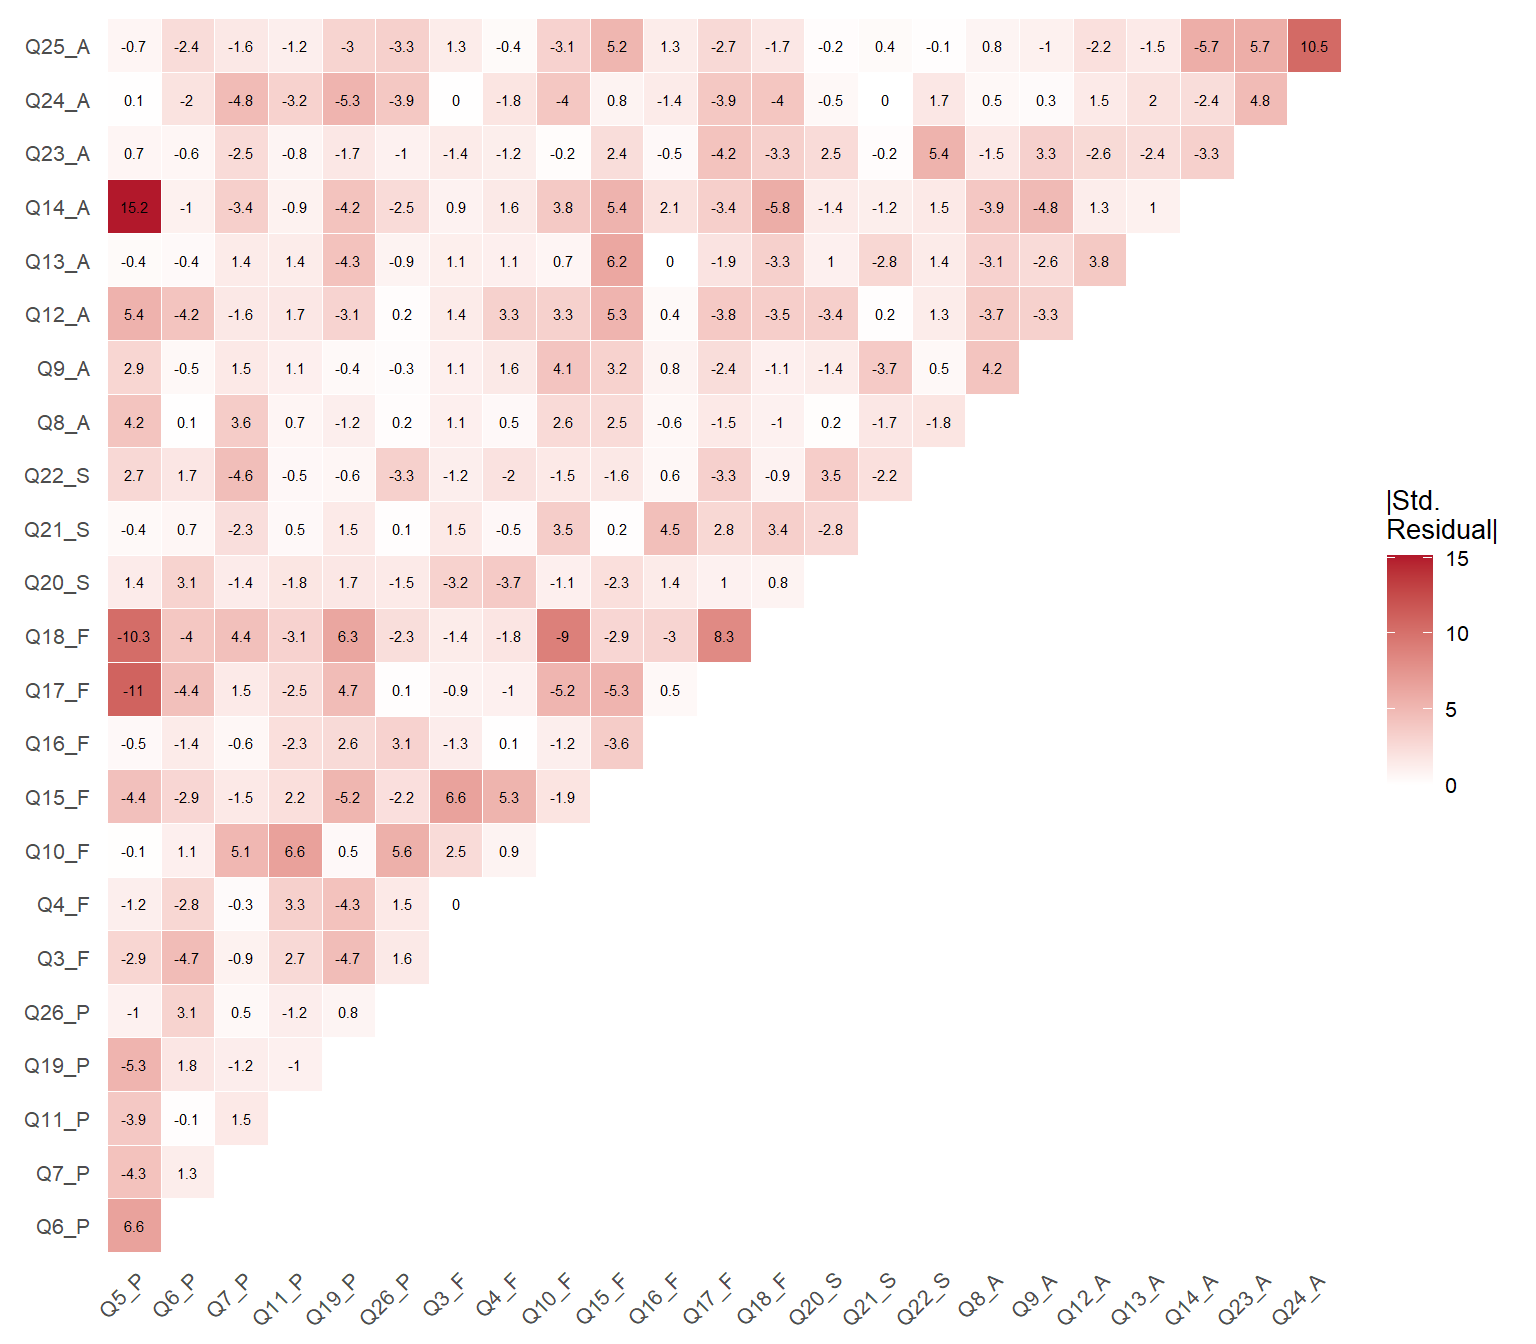

In [ ]:
res_std <- residuals(est_4fa, type = "standardized")$cov
res_std[upper.tri(res_std)] <- NA
diag(res_std) <- NA

res_long <- reshape2::melt(res_std, na.rm = TRUE)
names(res_long) <- c("Item1", "Item2", "value")
res_long$abs_value <- abs(res_long$value)

ggplot(res_long, aes(x = Item2, y = Item1, fill = abs_value)) +
  geom_tile(color = "white") +
  scale_fill_gradient(
    low = "white", high = "#B2182B",
    limit = c(0, max(res_long$abs_value)),
    name = "|Std.\nResidual|"
  ) +
  geom_text(aes(label = round(value, 1)), size = 2) +
  theme_minimal(base_size = 10) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1),
    axis.title = element_blank(),
    panel.grid = element_blank()
  ) +
  coord_fixed()

@fig-residuals-4f provides a global view of local misfit. Color intensity reflects the absolute magnitude of standardized residuals — darker red indicates poorer reproduction of that pairwise correlation by the model, regardless of direction. Cell labels retain the sign: positive values indicate the model underestimates the correlation, negative values indicate overestimation. Pairs exceeding \|2\| deserve closer inspection.

The residual analysis confirms the patterns identified by the modification indices: the largest standardized residuals involve Q5 and items from other domains, reinforcing the conclusion that this item introduces systematic misfit.

#### Reliability Coefficients

We compute reliability using `semTools::reliability()`, which provides: alpha (Cronbach’s), omega (composite reliability, preferred for CFA), omega2 (Bentler’s), omega3 (McDonald’s), and AVE (average variance extracted). AVE \> .50 indicates that the factor captures more variance from its items than is due to measurement error.

In [ ]:
knitr::kable(semTools::reliability(est_4fa), digits = 3)

Warning in semTools::reliability(est_4fa): 
The reliability() function was deprecated in 2022 and will cease to be included in future versions of semTools. See help('semTools-deprecated) for details.

It is replaced by the compRelSEM() function, which can estimate alpha and model-based reliability in an even wider variety of models and data types, with greater control in specifying the desired type of reliability coefficient (i.e., more explicitly choosing assumptions). 

The average variance extracted should never have been included because it is not a reliability coefficient. It is now available from the AVE() function.

For constructs with categorical indicators, Zumbo et al.`s (2007) "ordinal alpha" is calculated in addition to the standard alpha, which treats ordinal variables as numeric. See Chalmers (2018) for a critique of "alpha.ord" and the response by Zumbo & Kroc (2019). Likewise, average variance extracted is calculated from polychoric (polyserial) not Pearson correlations.

                psycho   physical   social   environment
  ----------- -------- ---------- -------- -------------
  alpha          0.820      0.823    0.687         0.787
  alpha.ord      0.854      0.863    0.741         0.820
  omega          0.821      0.801    0.707         0.794
  omega2         0.821      0.801    0.707         0.794
  omega3         0.823      0.811    0.723         0.797
  avevar         0.504      0.500    0.524         0.375


All four domains show composite reliability (omega) above .70, indicating adequate internal consistency. The AVE values are acceptable for most domains, with the Environment domain showing a slightly lower value — consistent with its broader and more heterogeneous item content. The Social domain, despite having only three items, shows strong reliability due to the high factor loadings of Q20, Q21, and Q22.

#### Preliminary Evaluation Summary

Based on the overall and local fit analysis:

-   **Overall fit is mediocre**, compatible with a Level 2 misspecification (DFI)
-   **Local indices indicate**: (a) high correlation between Physical and Psychological factors (suggesting potential hierarchical structure);
    1.  low factor loadings for Q4 and Q24; (c) **item Q5 is systematically problematic** — it appears in many high MIs and contributes to local misfit
-   **Reliability is adequate** for all domains

### Path Diagrams

The path diagram below visualize the estimated model. Latent factors are shown as ovals, observed items as rectangles, and standardized factor loadings as edge labels. The circle layout better displays interfactor correlations.

> **Layout Note**
>
> Consider this layout for educational purposes, as for your article you should create something better formatted, which will almost always be done by hand.

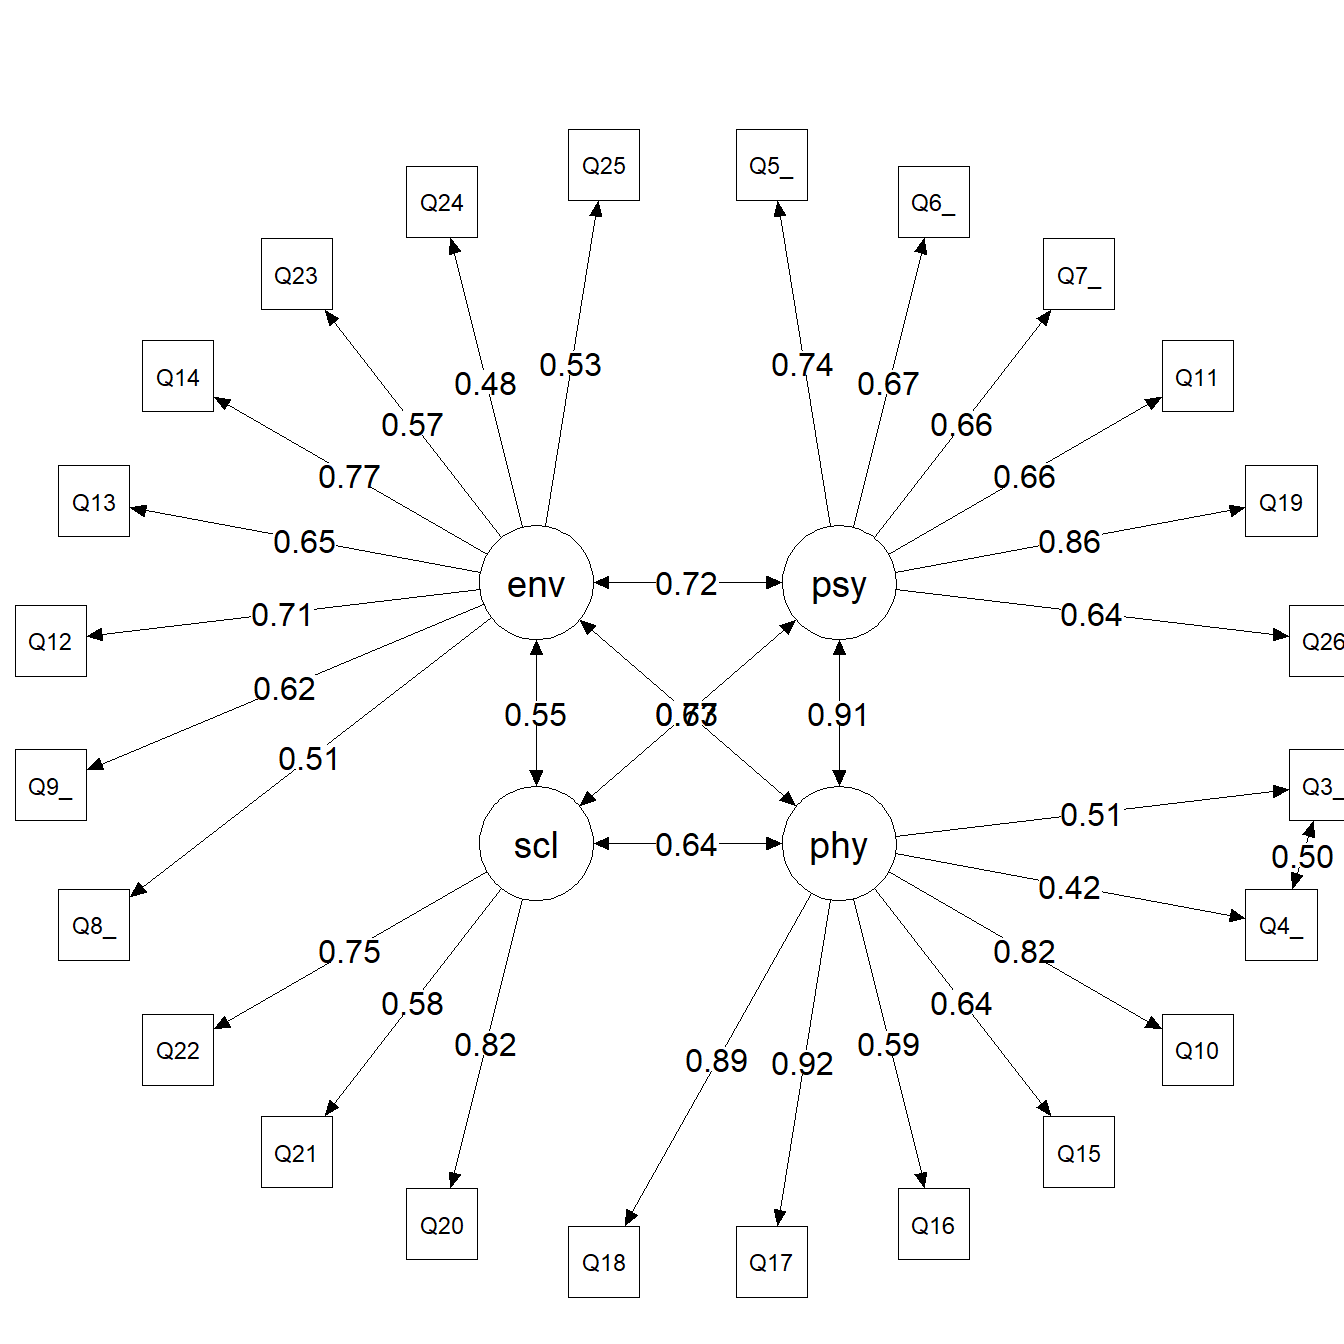

In [ ]:
sem_model_4fa <- semPlot::semPlotModel(est_4fa)

semPlot::semPaths(
  sem_model_4fa,
  what = "std",
  style = "lisrel",
  layout = "circle",
  intercepts = FALSE,
  thresholds = FALSE,
  residuals = FALSE,
  edge.label.cex = 1,
  label.cex = 1,
  weighted = FALSE,
  edge.color = "black",
  mar = c(1.5, 0.8, 3, 0.3)
)

The circle layout in @fig-diagram-4f-circle reveals the strong correlations among all four factors, particularly between Psychological and Physical domains. This pattern motivates the exploration of bifactor and second-order models in the following sections.

## 4-Factor Bifactor Model

Given the high interfactor correlations observed in the 4-factor model, a bifactor structure is a natural alternative. In a bifactor model, a general factor (here, overall Quality of Life — QOL) loads directly on all items alongside specific group factors for each domain. The critical assumption is that all factors — general and specific — are **orthogonal** (uncorrelated).

This model tests whether there is a meaningful general QOL construct underlying all items, and how much unique variance remains in each specific domain after accounting for the general factor. Item Q5 is excluded from this model due to convergence problems, which further supports the preliminary evidence that Q5 is problematic.

> **On Bifactor Models**
>
> Bifactor models have gained popularity in psychometrics because they often provide better fit indices than correlated-factor models. However, as discussed in @rogers2024, some authors argue that this improved fit is partly an artifact of the greater number of parameters, and that the orthogonality assumption rarely holds in practice. These considerations will be important when comparing models.

### Model Specification

In bifactor model syntax, the **general factor must be specified first**. The Q3–Q4 residual correlation is no longer needed because both items now load on the general factor, which absorbs their shared variance.

In [ ]:
spe_4f_bi <- "
QOL =~ Q6_P + Q7_P + Q11_P + Q19_P + Q26_P + Q3_F + Q4_F + Q10_F + Q15_F + Q16_F + Q17_F + Q18_F + Q20_S + Q21_S + Q22_S + Q8_A + Q9_A + Q12_A + Q13_A + Q14_A + Q23_A + Q24_A + Q25_A
psycho =~ Q6_P + Q7_P + Q11_P + Q19_P + Q26_P
physical =~ Q3_F + Q4_F + Q10_F + Q15_F + Q16_F + Q17_F + Q18_F
social =~ Q20_S + Q21_S + Q22_S
environment =~ Q8_A + Q9_A + Q12_A + Q13_A + Q14_A + Q23_A + Q24_A + Q25_A
"

### Model Estimation

The `orthogonal = TRUE` argument is **required** for bifactor models, enforcing zero correlations between all factors.

In [ ]:
est_4f_bi <- cfa(spe_4f_bi,
  data = df0,
  orthogonal = TRUE,
  ordered = TRUE,
  std.lv = TRUE,
  estimator = "WLSMV"
)

### Model Evaluation

In [ ]:
fit_names <- c("chisq.scaled", "df.scaled", "pvalue.scaled",
               "cfi.scaled", "tli.scaled",
               "rmsea.scaled", "rmsea.ci.lower.scaled", "rmsea.ci.upper.scaled",
               "srmr")
fi <- fitmeasures(est_4f_bi, fit_names)

fit_df <- data.frame(
  `χ²`     = round(fi["chisq.scaled"], 2),
  df       = fi["df.scaled"],
  p        = round(fi["pvalue.scaled"], 3),
  CFI      = round(fi["cfi.scaled"], 3),
  TLI      = round(fi["tli.scaled"], 3),
  RMSEA    = round(fi["rmsea.scaled"], 3),
  `RMSEA 90% CI` = paste0("[", round(fi["rmsea.ci.lower.scaled"], 3),
                           ", ", round(fi["rmsea.ci.upper.scaled"], 3), "]"),
  SRMR     = round(fi["srmr"], 3),
  check.names = FALSE
)
rownames(fit_df) <- NULL
knitr::kable(fit_df)

         χ²    df   p     CFI     TLI   RMSEA RMSEA 90% CI          SRMR
  --------- ----- --- ------- ------- ------- ------------------ -------
    1212.68   207   0   0.958   0.949   0.068 \[0.064, 0.072\]     0.049


In [ ]:
params <- standardizedSolution(est_4f_bi)
loadings <- params[params$op == "=~",
                   c("lhs", "rhs", "est.std", "se", "pvalue")]
names(loadings) <- c("Factor", "Item", "Std.Loading", "SE", "p")
loadings$Std.Loading <- round(loadings$Std.Loading, 3)
loadings$SE <- round(loadings$SE, 3)
loadings$p <- ifelse(loadings$p < 0.001, "< .001",
                     round(loadings$p, 3))
rownames(loadings) <- NULL
knitr::kable(loadings)

  Factor        Item      Std.Loading      SE p
  ------------- ------- ------------- ------- ---------
  QOL           Q6_P            0.632   0.022 \< .001
  QOL           Q7_P            0.668   0.019 \< .001
  QOL           Q11_P           0.666   0.020 \< .001
  QOL           Q19_P           0.851   0.012 \< .001
  QOL           Q26_P           0.634   0.022 \< .001
  QOL           Q3_F            0.422   0.030 \< .001
  QOL           Q4_F            0.349   0.031 \< .001
  QOL           Q10_F           0.785   0.014 \< .001
  QOL           Q15_F           0.584   0.027 \< .001
  QOL           Q16_F           0.573   0.023 \< .001
  QOL           Q17_F           0.875   0.012 \< .001
  QOL           Q18_F           0.842   0.013 \< .001
  QOL           Q20_S           0.598   0.021 \< .001
  QOL           Q21_S           0.452   0.026 \< .001
  QOL           Q22_S           0.541   0.024 \< .001
  QOL           Q8_A            0.372   0.028 \< .001
  QOL           Q9_A            0.454   0.026 \< .001
  QOL           Q12_A           0.499   0.024 \< .001
  QOL           Q13_A           0.461   0.025 \< .001
  QOL           Q14_A           0.527   0.024 \< .001
  QOL           Q23_A           0.380   0.029 \< .001
  QOL           Q24_A           0.246   0.031 \< .001
  QOL           Q25_A           0.328   0.029 \< .001
  psycho        Q6_P            0.696   0.479 0.146
  psycho        Q7_P            0.059   0.051 0.247
  psycho        Q11_P           0.021   0.032 0.502
  psycho        Q19_P           0.085   0.066 0.2
  psycho        Q26_P           0.135   0.102 0.184
  physical      Q3_F            0.690   0.042 \< .001
  physical      Q4_F            0.606   0.039 \< .001
  physical      Q10_F           0.116   0.030 \< .001
  physical      Q15_F           0.290   0.037 \< .001
  physical      Q16_F           0.059   0.037 0.107
  physical      Q17_F           0.268   0.031 \< .001
  physical      Q18_F           0.257   0.031 \< .001
  social        Q20_S           0.566   0.052 \< .001
  social        Q21_S           0.269   0.035 \< .001
  social        Q22_S           0.567   0.052 \< .001
  environment   Q8_A            0.300   0.032 \< .001
  environment   Q9_A            0.386   0.029 \< .001
  environment   Q12_A           0.485   0.026 \< .001
  environment   Q13_A           0.453   0.028 \< .001
  environment   Q14_A           0.441   0.028 \< .001
  environment   Q23_A           0.468   0.029 \< .001
  environment   Q24_A           0.603   0.028 \< .001
  environment   Q25_A           0.518   0.027 \< .001


The bifactor model shows improved fit compared to the original 4-factor model, with slightly better CFI, TLI, and RMSEA values. However, the improvement is modest and the fit remains in the mediocre range (Level 2 of DFI).

Examining the standardized loadings, the general QOL factor captures substantial variance from most items. Notably, the **Psychological specific factor shows very low loadings** — most of the variance that was previously attributed to the Psychological domain is now absorbed by the general factor. This pattern suggests that psychological well-being items are primarily indicators of overall QOL rather than a distinct domain.

In [ ]:
mi_table <- modificationindices(est_4f_bi,
  sort. = TRUE,
  minimum.value = 3.84,
  maximum.number = 20
)

knitr::kable(
  mi_table[, 1:5],
  digits = 3
)

        lhs           op     rhs                  mi      epc
  ----- ------------- ------ ------------- --------- --------
  462   Q17_F         \~\~   Q18_F           155.946    0.215
  280   environment   =\~    Q15_F           114.813    0.300
  387   Q3_F          \~\~   Q4_F             58.434    0.819
  283   environment   =\~    Q18_F            46.170   -0.177
  286   environment   =\~    Q22_S            45.651    0.170
  539   Q24_A         \~\~   Q25_A            44.606    0.231
  282   environment   =\~    Q17_F            42.692   -0.170
  166   social        \~\~   environment      38.239    0.196
  269   social        =\~    Q23_A            36.821    0.232
  164   physical      \~\~   social           34.825   -0.274
  162   psycho        \~\~   social           33.459    0.280
  252   social        =\~    Q6_P             31.214    0.184
  526   Q12_A         \~\~   Q14_A            31.078    0.152
  509   Q22_S         \~\~   Q23_A            30.368    0.165
  512   Q8_A          \~\~   Q9_A             29.681    0.156
  391   Q3_F          \~\~   Q17_F            29.502   -0.244
  392   Q3_F          \~\~   Q18_F            28.622   -0.239
  448   Q15_F         \~\~   Q25_A            26.451    0.154
  241   physical      =\~    Q20_S            23.444   -0.174
  408   Q4_F          \~\~   Q18_F            23.223   -0.198


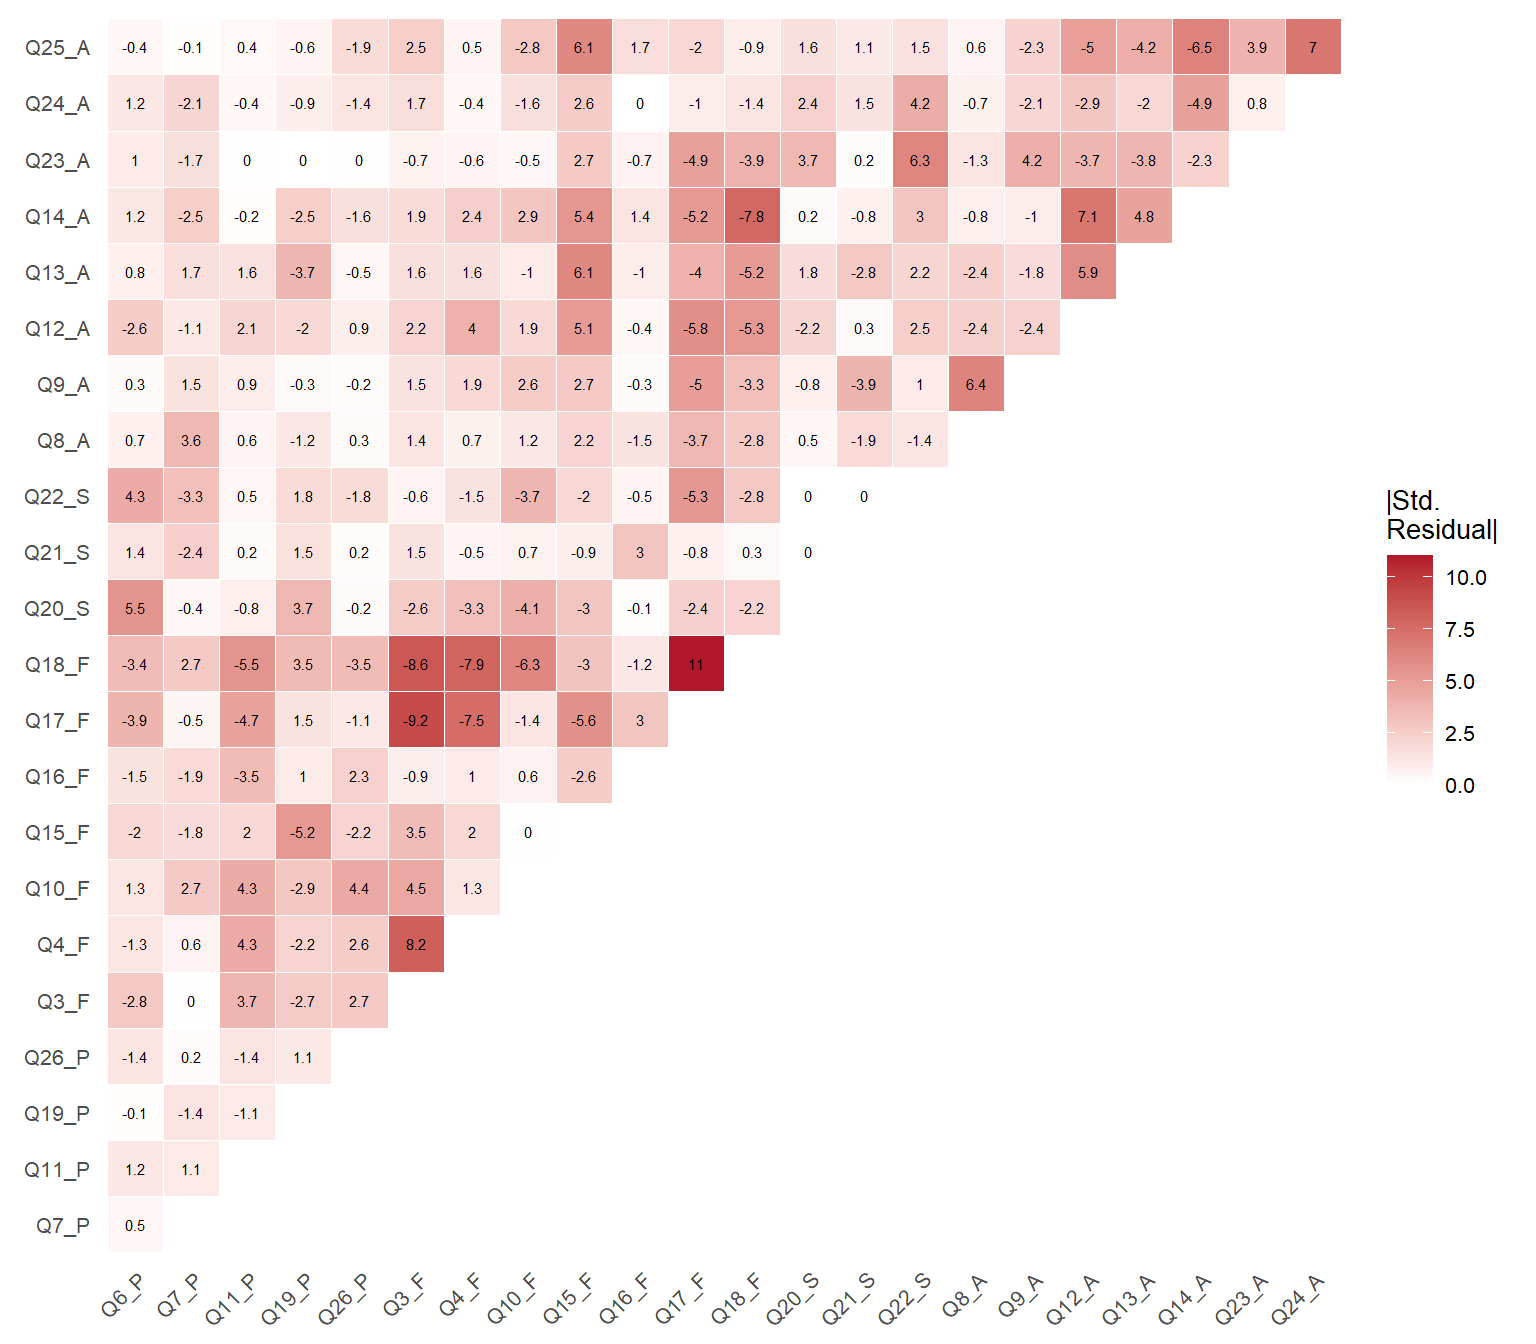

In [ ]:
res_std <- residuals(est_4f_bi, type = "standardized")$cov
res_std[upper.tri(res_std)] <- NA
diag(res_std) <- NA

res_long <- reshape2::melt(res_std, na.rm = TRUE)
names(res_long) <- c("Item1", "Item2", "value")
res_long$abs_value <- abs(res_long$value)

ggplot(res_long, aes(x = Item2, y = Item1, fill = abs_value)) +
  geom_tile(color = "white") +
  scale_fill_gradient(
    low = "white", high = "#B2182B",
    limit = c(0, max(res_long$abs_value)),
    name = "|Std.\nResidual|"
  ) +
  geom_text(aes(label = round(value, 1)), size = 2) +
  theme_minimal(base_size = 10) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1),
    axis.title = element_blank(),
    panel.grid = element_blank()
  ) +
  coord_fixed()

#### Reliability

For bifactor models, omega from `psych::omegaFromSem()` provides the most appropriate reliability decomposition: **omega hierarchical (ωH)** estimates the proportion of total score variance attributable to the general factor, while **omega subscale (ωS)** estimates the proportion attributable to each specific factor after controlling for the general factor.

In [ ]:
omega_obj <- psych::omegaFromSem(fit = est_4f_bi, plot = FALSE)

# Complete omega table
omega_complete <- data.frame(
  Dimension = c("General Factor", "Psychological", "Physical", 
                "Social", "Environmental"),
  `ω Total` = omega_obj$omega.group$total,
  `ω Hierarchical` = omega_obj$omega.group$general,
  `ω Group` = omega_obj$omega.group$group,
  check.names = FALSE
)

knitr::kable(
  omega_complete,
  digits = 3,
  caption = "Omega Coefficients - Bifactor Model",
  align = c("l", "c", "c", "c"),
  col.names = c("Dimension", "ωT", "ωH", "ωS")
)

  Dimension          ωT      ωH      ωS
  ---------------- ------- ------- -------
  General Factor    0.942   0.837   0.111
  Psychological     0.864   0.797   0.067
  Physical          0.926   0.731   0.195
  Social            0.758   0.427   0.331
  Environmental     0.847   0.376   0.471

  : Omega Coefficients - Bifactor Model


The omega hierarchical value indicates that the general QOL factor accounts for a substantial proportion of reliable variance. The Psychological specific factor contributes very little unique reliable variance beyond the general factor, confirming the pattern observed in the loadings. The Physical, Social, and Environment specific factors retain more meaningful unique variance.

#### Preliminary Evaluation Summary

-   **Overall fit has improved** but remains mediocre (Level 2 of DFI, although not directly comparable)
-   The **general (G) factor is statistically relevant** and explains substantial variance across all items
-   The **Psychological specific factor loses most of its importance** — its variance is almost entirely captured by the general QOL factor
-   The orthogonality assumption required for this model is a strong restriction that may not hold empirically

### Path Diagram

The `tree3` layout is specifically designed for bifactor diagrams, placing the general factor centrally and specific factors on the sides.

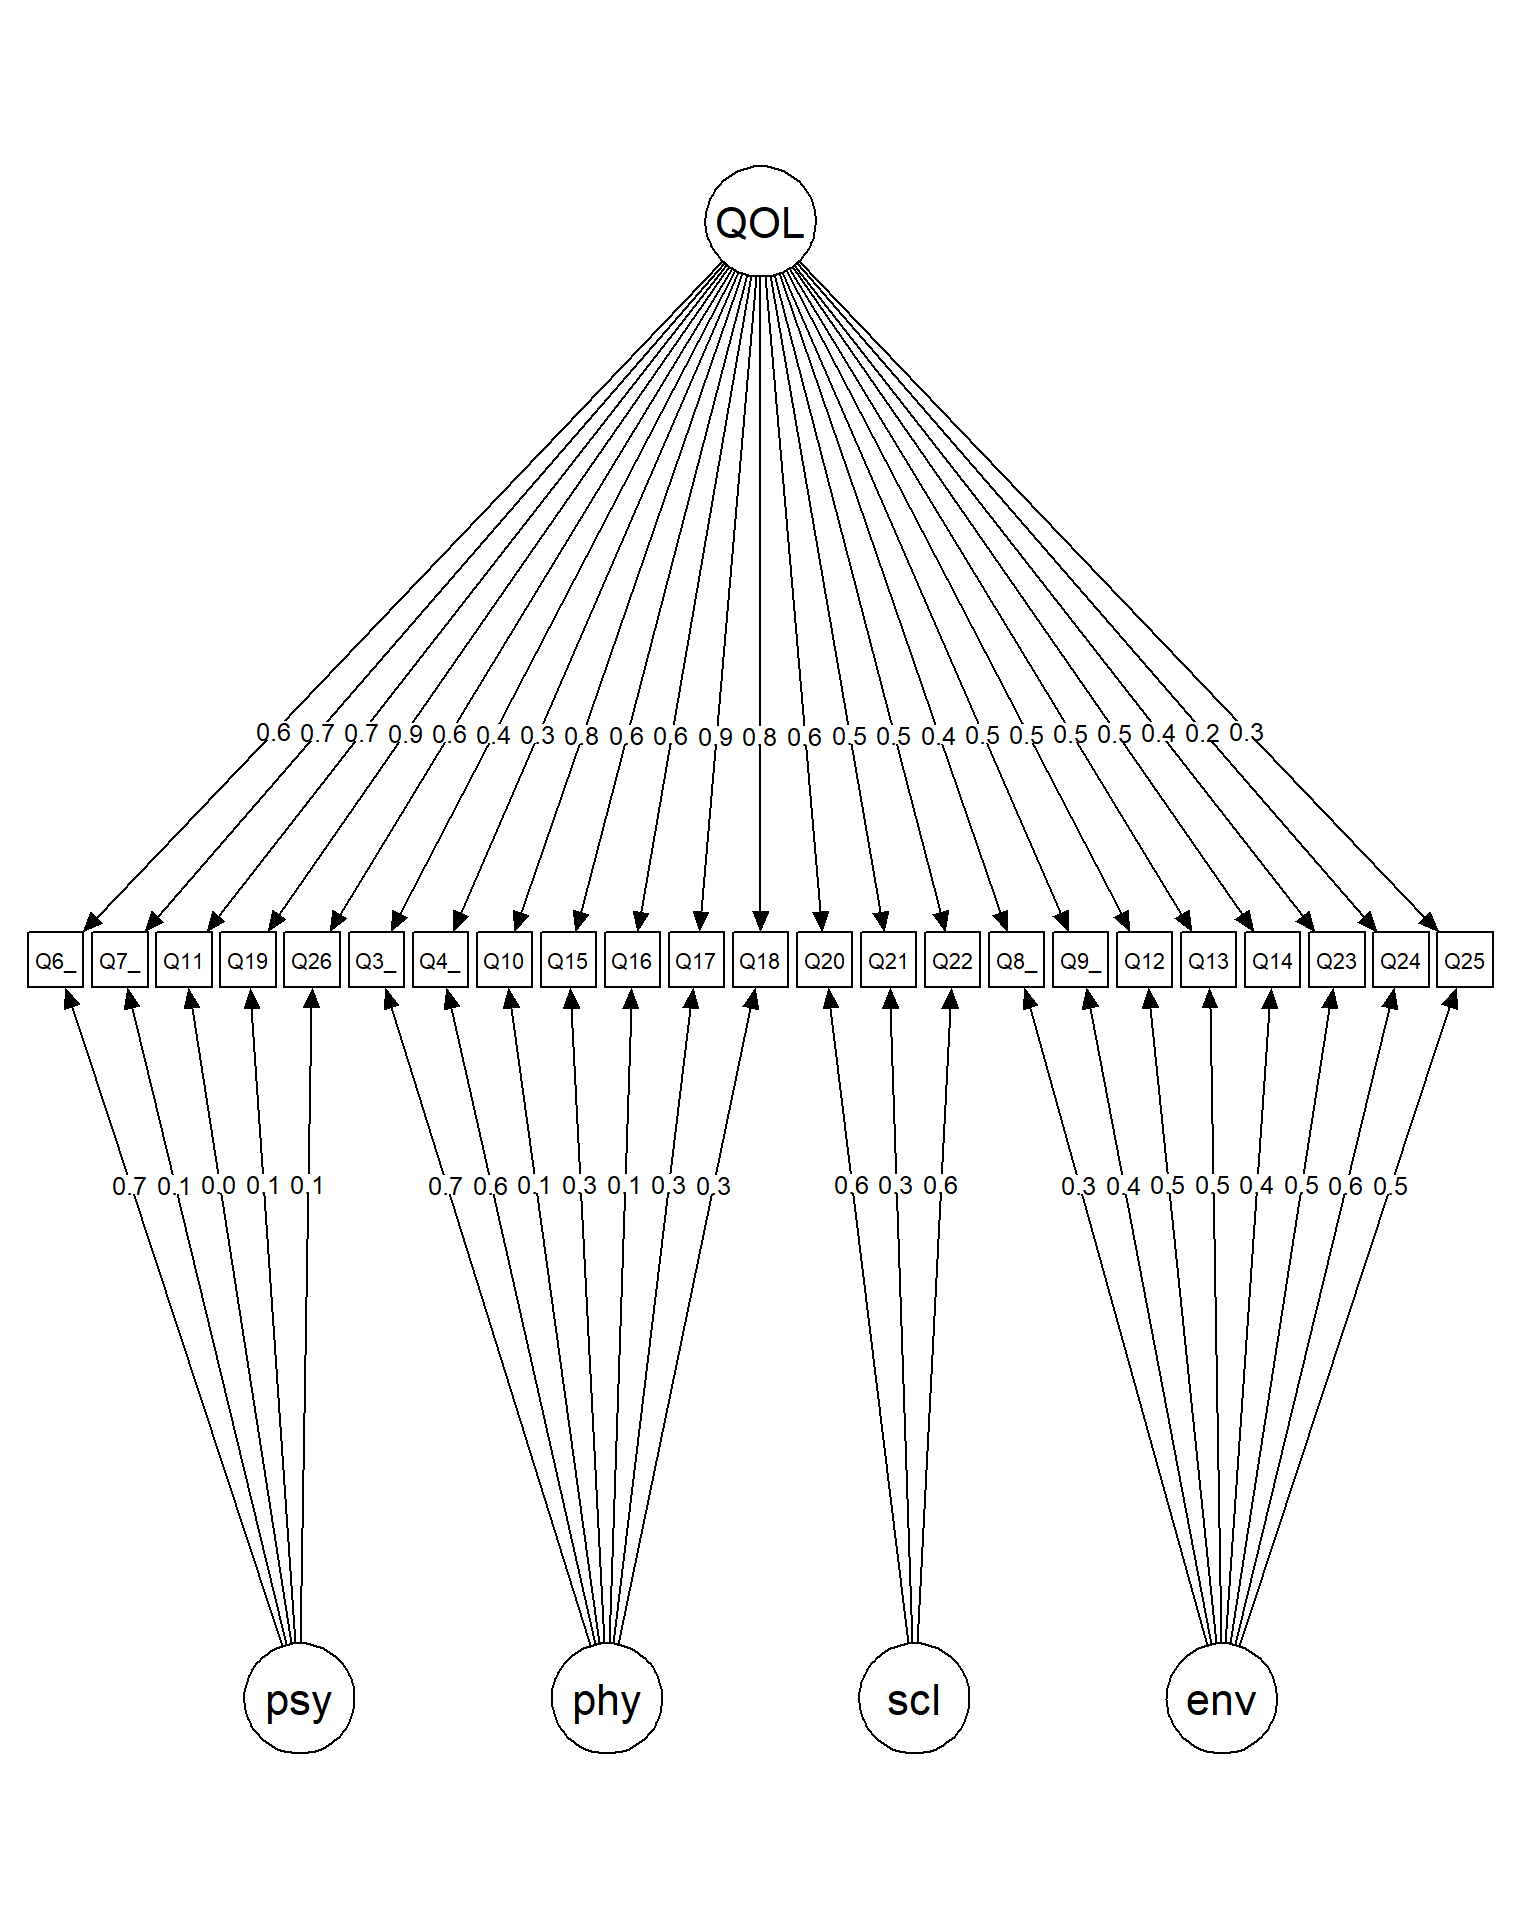

In [ ]:
sem_model_bi <- semPlot::semPlotModel(est_4f_bi)

semPlot::semPaths(
  sem_model_bi,
  what = "std",
  style = "lisrel",
  layout = "tree3",
  intercepts = FALSE,
  thresholds = FALSE,
  residuals = FALSE,
  edge.label.cex = 0.6,
  nDigits = 1,
  sizeMan = 3,
  sizeLat = 6, 
  label.cex = 1.2,
  weighted = FALSE,
  edge.color = "black",
  bifactor = "QOL",
  edge.label.position = 0.7,
  mar = c(3, 0.8, 3, 1)
)

> **Path Diagram Layout**
>
> You can test other formatting parameters (edge.label.cex, label.cex, edge.label.position, etc) to simulate path diagrams with better layouts.

## Second-Order CFA Model

An alternative to the bifactor model is the second-order (hierarchical) model. Here, the general QOL factor does **not** load directly on items. Instead, it loads on the four first-order factors, which in turn load on the observed items. This structure implies that the influence of the general factor on individual items is *mediated* by the domain-specific factors — a conceptually different interpretation from the bifactor model.

### Model Specification

Item Q5 is excluded for comparability with the bifactor model. A technical requirement is that the Psychological factor variance must be fixed to zero for model convergence (empirical underidentification), suggesting that essentially all Psychological domain variance is explained by the higher-order QOL factor.

In [ ]:
spe_4f_2or <- "
psycho =~ Q6_P + Q7_P + Q11_P + Q19_P + Q26_P
physical =~ Q3_F + Q4_F + Q10_F + Q15_F + Q16_F + Q17_F + Q18_F
social =~ Q20_S + Q21_S + Q22_S
environment =~ Q8_A + Q9_A + Q12_A + Q13_A + Q14_A + Q23_A + Q24_A + Q25_A
QOL =~ psycho + physical + social + environment
Q3_F ~~ Q4_F
psycho ~~ 0*psycho
"

> **Convergence Note**
>
> Fixing the Psychological factor variance to zero (`psycho ~~ 0*psycho`) is necessary for model convergence. This is not merely a technical trick — it has substantive meaning: nearly all variance in the Psychological domain is captured by the general QOL factor. This finding is consistent with the bifactor results, where the Psychological specific factor had minimal importance.

### Model Estimation

Note that `std.lv` is not used here because the second-order structure imposes its own identification constraints through the higher-order factor loadings.

In [ ]:
est_4f_2or <- cfa(
  spe_4f_2or,
  data = df0,
  ordered = TRUE,
  estimator = "WLSMV"
)

### Model Evaluation

The second-order model fit is comparable to the other models, though the convergence issue with the Psychological domain is a notable limitation. The second-order loadings (QOL → first-order factors) reveal the relative contribution of each domain to overall quality of life.

In [ ]:
fit_names <- c("chisq.scaled", "df.scaled", "pvalue.scaled",
               "cfi.scaled", "tli.scaled",
               "rmsea.scaled", "rmsea.ci.lower.scaled", "rmsea.ci.upper.scaled",
               "srmr")
fi <- fitmeasures(est_4f_2or, fit_names)

fit_df <- data.frame(
  `χ²`     = round(fi["chisq.scaled"], 2),
  df       = fi["df.scaled"],
  p        = round(fi["pvalue.scaled"], 3),
  CFI      = round(fi["cfi.scaled"], 3),
  TLI      = round(fi["tli.scaled"], 3),
  RMSEA    = round(fi["rmsea.scaled"], 3),
  `RMSEA 90% CI` = paste0("[", round(fi["rmsea.ci.lower.scaled"], 3),
                           ", ", round(fi["rmsea.ci.upper.scaled"], 3), "]"),
  SRMR     = round(fi["srmr"], 3),
  check.names = FALSE
)
rownames(fit_df) <- NULL
knitr::kable(fit_df)

         χ²    df   p     CFI     TLI   RMSEA RMSEA 90% CI          SRMR
  --------- ----- --- ------- ------- ------- ------------------ -------
    1285.17   226   0   0.956   0.951   0.067 \[0.063, 0.071\]     0.054


In [ ]:
params <- standardizedSolution(est_4f_2or)
loadings <- params[params$op == "=~",
                   c("lhs", "rhs", "est.std", "se", "pvalue")]
names(loadings) <- c("Factor", "Item", "Std.Loading", "SE", "p")
loadings$Std.Loading <- round(loadings$Std.Loading, 3)
loadings$SE <- round(loadings$SE, 3)
loadings$p <- ifelse(loadings$p < 0.001, "< .001",
                     round(loadings$p, 3))
rownames(loadings) <- NULL
knitr::kable(loadings)

  Factor        Item            Std.Loading      SE p
  ------------- ------------- ------------- ------- ---------
  psycho        Q6_P                  0.660   0.019 \< .001
  psycho        Q7_P                  0.678   0.018 \< .001
  psycho        Q11_P                 0.671   0.020 \< .001
  psycho        Q19_P                 0.872   0.012 \< .001
  psycho        Q26_P                 0.648   0.020 \< .001
  physical      Q3_F                  0.509   0.026 \< .001
  physical      Q4_F                  0.422   0.029 \< .001
  physical      Q10_F                 0.811   0.012 \< .001
  physical      Q15_F                 0.642   0.025 \< .001
  physical      Q16_F                 0.590   0.023 \< .001
  physical      Q17_F                 0.923   0.007 \< .001
  physical      Q18_F                 0.888   0.009 \< .001
  social        Q20_S                 0.818   0.019 \< .001
  social        Q21_S                 0.588   0.027 \< .001
  social        Q22_S                 0.747   0.020 \< .001
  environment   Q8_A                  0.510   0.028 \< .001
  environment   Q9_A                  0.630   0.025 \< .001
  environment   Q12_A                 0.715   0.021 \< .001
  environment   Q13_A                 0.663   0.023 \< .001
  environment   Q14_A                 0.731   0.021 \< .001
  environment   Q23_A                 0.579   0.027 \< .001
  environment   Q24_A                 0.492   0.028 \< .001
  environment   Q25_A                 0.541   0.027 \< .001
  QOL           psycho                1.000   0.000 NA
  QOL           physical              0.912   0.010 \< .001
  QOL           social                0.740   0.020 \< .001
  QOL           environment           0.685   0.021 \< .001


In [ ]:
mi_table <- modificationindices(est_4f_2or,
  sort. = TRUE,
  minimum.value = 3.84,
  maximum.number = 20
)

knitr::kable(
  mi_table[, 1:5],
  digits = 3
)

        lhs           op     rhs            mi      epc
  ----- ------------- ------ ------- --------- --------
  533   Q24_A         \~\~   Q25_A     115.469    0.274
  252   environment   =\~    Q15_F      94.778    0.673
  456   Q17_F         \~\~   Q18_F      82.991    0.156
  206   psycho        =\~    Q24_A      74.190   -0.449
  280   QOL           =\~    Q24_A      74.190   -0.449
  222   physical      =\~    Q24_A      72.314   -0.523
  192   psycho        =\~    Q10_F      54.814    1.152
  266   QOL           =\~    Q10_F      54.814    1.152
  255   environment   =\~    Q18_F      36.927   -0.394
  254   environment   =\~    Q17_F      36.682   -0.395
  417   Q10_F         \~\~   Q18_F      32.049   -0.119
  383   Q3_F          \~\~   Q15_F      31.584    0.179
  195   psycho        =\~    Q17_F      28.227   -0.929
  269   QOL           =\~    Q17_F      28.227   -0.929
  242   social        =\~    Q24_A      27.741   -0.206
  503   Q22_S         \~\~   Q23_A      24.588    0.147
  532   Q23_A         \~\~   Q25_A      24.194    0.141
  208   physical      =\~    Q6_P       22.864   -1.054
  215   physical      =\~    Q22_S      22.662   -0.599
  438   Q15_F         \~\~   Q13_A      22.272    0.148


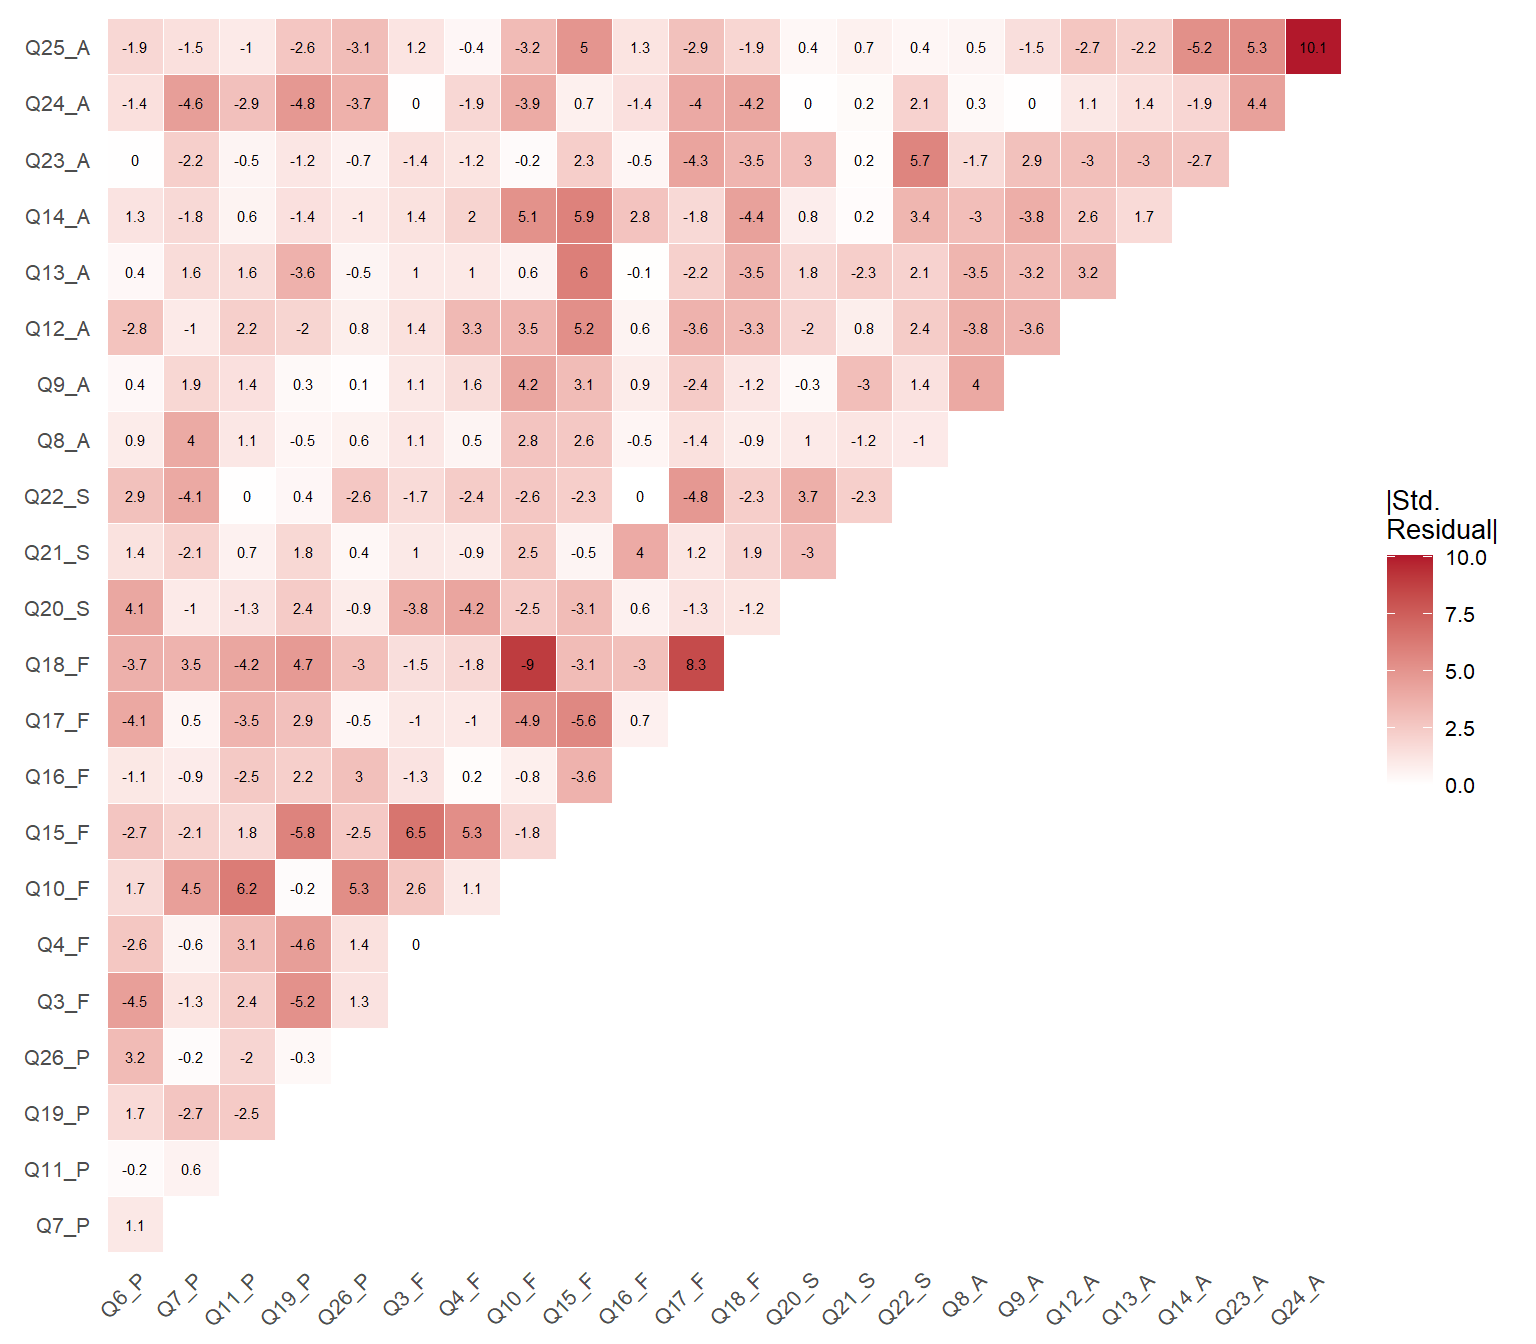

In [ ]:
res_std <- residuals(est_4f_2or, type = "standardized")$cov
res_std[upper.tri(res_std)] <- NA
diag(res_std) <- NA

res_long <- reshape2::melt(res_std, na.rm = TRUE)
names(res_long) <- c("Item1", "Item2", "value")
res_long$abs_value <- abs(res_long$value)

ggplot(res_long, aes(x = Item2, y = Item1, fill = abs_value)) +
  geom_tile(color = "white") +
  scale_fill_gradient(
    low = "white", high = "#B2182B",
    limit = c(0, max(res_long$abs_value)),
    name = "|Std.\nResidual|"
  ) +
  geom_text(aes(label = round(value, 1)), size = 2) +
  theme_minimal(base_size = 10) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1),
    axis.title = element_blank(),
    panel.grid = element_blank()
  ) +
  coord_fixed()

#### Reliability

For the first-order factors, we use `semTools::reliability()`. For the second-order QOL factor, `semTools::reliabilityL2()` provides the appropriate decomposition.

In [ ]:
knitr::kable(semTools::reliability(est_4f_2or), digits = 3)

Warning in semTools::reliability(est_4f_2or): 
The reliability() function was deprecated in 2022 and will cease to be included in future versions of semTools. See help('semTools-deprecated) for details.

It is replaced by the compRelSEM() function, which can estimate alpha and model-based reliability in an even wider variety of models and data types, with greater control in specifying the desired type of reliability coefficient (i.e., more explicitly choosing assumptions). 

The average variance extracted should never have been included because it is not a reliability coefficient. It is now available from the AVE() function.

For constructs with categorical indicators, Zumbo et al.`s (2007) "ordinal alpha" is calculated in addition to the standard alpha, which treats ordinal variables as numeric. See Chalmers (2018) for a critique of "alpha.ord" and the response by Zumbo & Kroc (2019). Likewise, average variance extracted is calculated from polychoric (polyserial) not Pearson correlations.

                psycho   physical   social   environment
  ----------- -------- ---------- -------- -------------
  alpha          0.793      0.823    0.687         0.787
  alpha.ord      0.831      0.863    0.741         0.820
  omega          0.794      0.801    0.708         0.795
  omega2         0.794      0.801    0.708         0.795
  omega3         0.794      0.810    0.725         0.802
  avevar         0.505      0.499    0.525         0.377


In [ ]:
knitr::kable(as.data.frame(t(semTools::reliabilityL2(est_4f_2or, "QOL"))), digits = 3)

Warning in semTools::reliabilityL2(est_4f_2or, "QOL"): 
The reliabilityL2() function was deprecated in 2022 and will cease to be included in future versions of semTools. See help('semTools-deprecated) for details.

It is replaced by the compRelSEM() function, which can estimate alpha and model-based reliability in an even wider variety of models and data types, with greater control in specifying the desired type of reliability coefficient (i.e., more explicitly choosing assumptions).

    omegaL1   omegaL2   partialOmegaL1
  --------- --------- ----------------
      0.838     0.899            0.926


The second-order QOL factor shows adequate reliability, indicating that the four first-order domains collectively serve as reliable indicators of overall quality of life. First-order reliability values remain consistent with those observed in the standard 4-factor model.

### Path Diagram

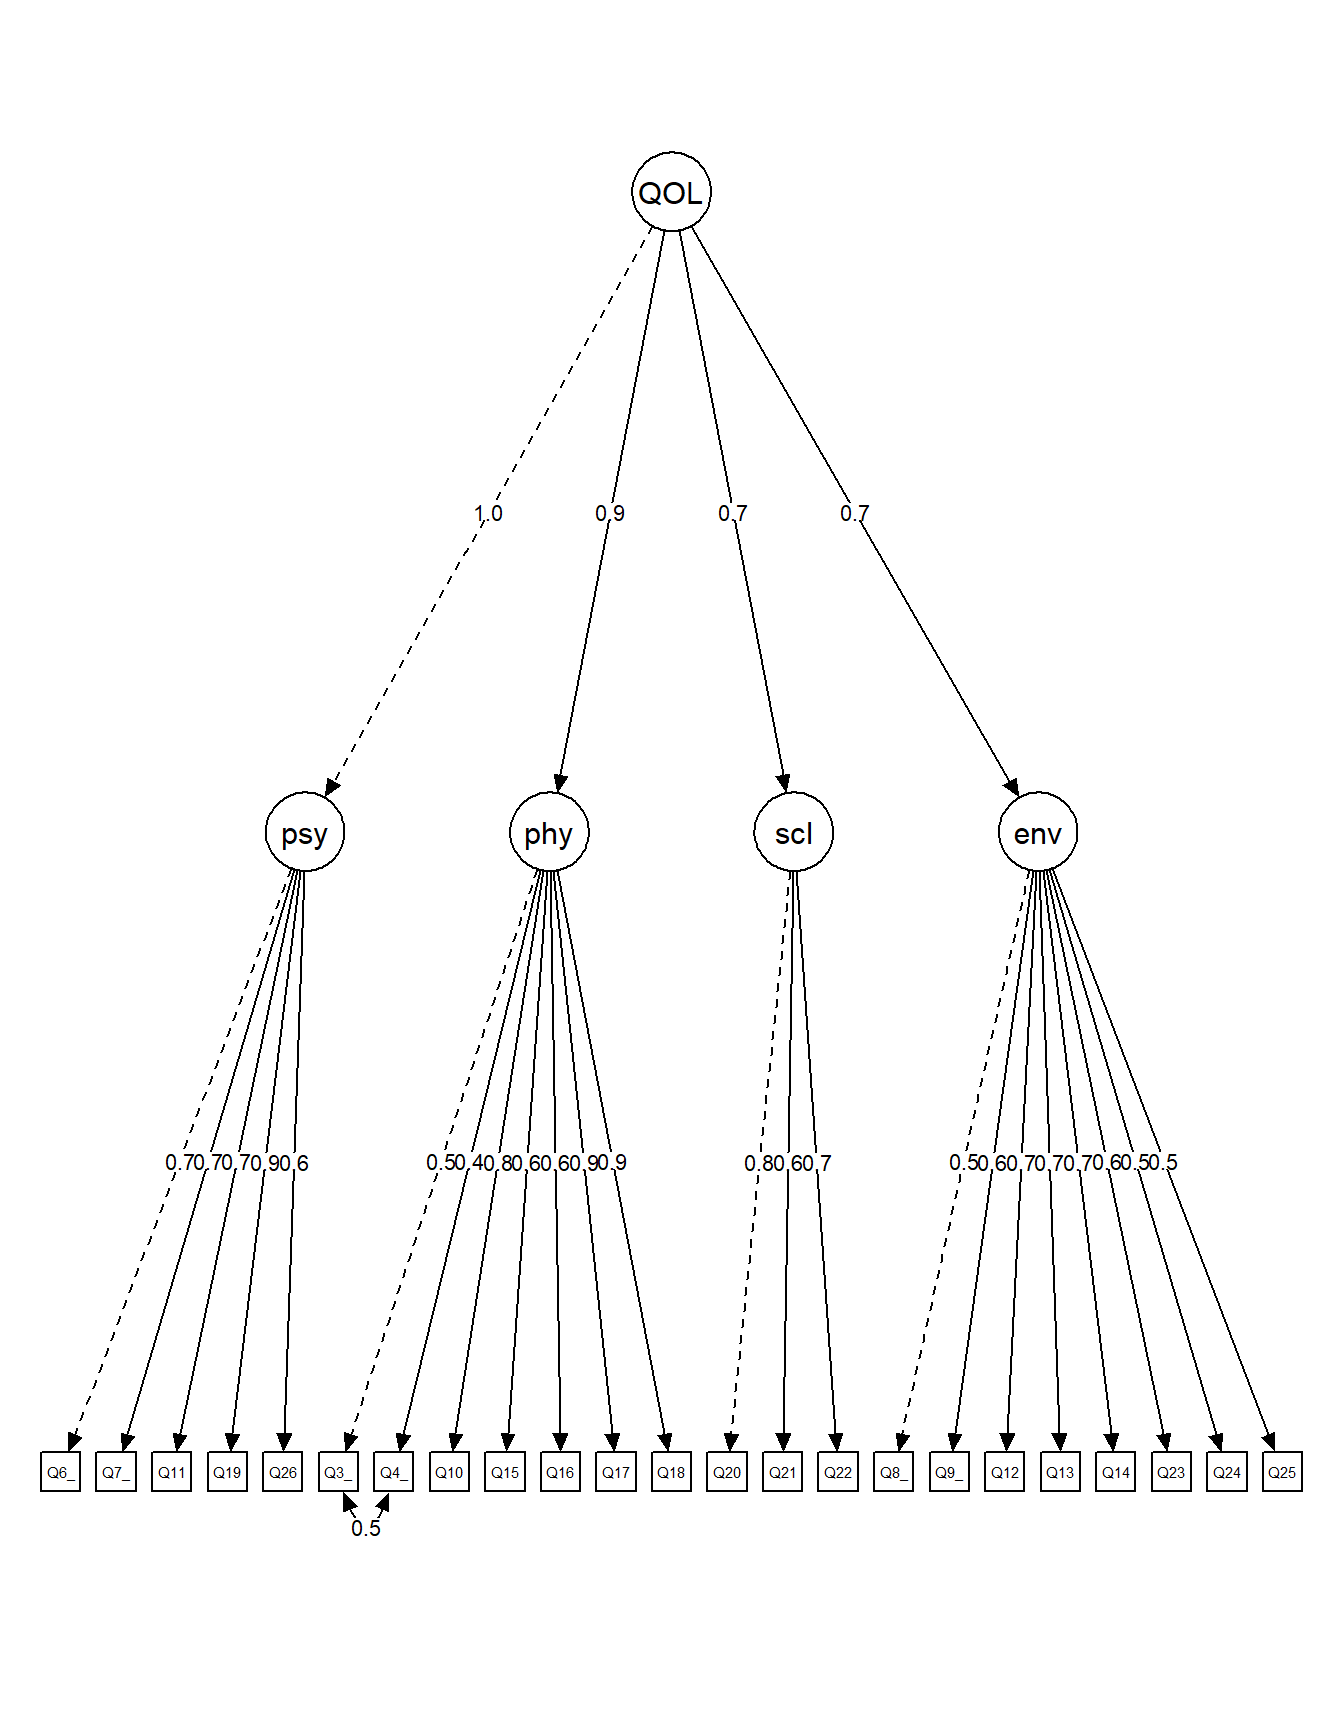

In [ ]:
sem_model_2or <- semPlot::semPlotModel(est_4f_2or)

semPlot::semPaths(
  sem_model_2or,
  what = "std",
  style = "lisrel",
  layout = "tree",
  intercepts = FALSE,
  thresholds = FALSE,
  residuals = FALSE,
  edge.label.cex = 0.6,
  nDigits = 1,
  sizeMan = 3,
  sizeLat = 6,
  label.cex = 1.2,
  weighted = FALSE,
  edge.color = "black",
  node.width = 0.8,
  mar = c(4, 1, 3, 1)
)

## 4-Factor Model Without Item Q5

The analyses above converged on a consistent finding: **item Q5 is problematic**. It appeared in multiple high modification indices in the original 4-factor model, caused convergence problems in the bifactor model, and its removal was necessary for comparability across alternative models. This is a common scenario in applied CFA — items that appear sound from a content validity perspective may not perform well empirically in a given sample or cultural context.

### Model Specification

This section presents the revised 4-factor model excluding Q5, retaining the correlated residuals between Q3 and Q4. This model will serve as the basis for the final model comparison and post hoc power analysis.

In [ ]:
spe_4fb <- "
psycho =~ Q6_P + Q7_P + Q11_P + Q19_P + Q26_P
physical =~ Q3_F + Q4_F + Q10_F + Q15_F + Q16_F + Q17_F + Q18_F
social =~ Q20_S + Q21_S + Q22_S
environment =~ Q8_A + Q9_A + Q12_A + Q13_A + Q14_A + Q23_A + Q24_A + Q25_A
Q4_F ~~ Q3_F
"

### Model Estimation

In [ ]:
est_4fb <- cfa(
  spe_4fb,
  data = df0,
  ordered = TRUE,
  std.lv = TRUE,
  estimator = "WLSMV"
)

### Model Evaluation

In [ ]:
fit_names <- c("chisq.scaled", "df.scaled", "pvalue.scaled",
               "cfi.scaled", "tli.scaled",
               "rmsea.scaled", "rmsea.ci.lower.scaled", "rmsea.ci.upper.scaled",
               "srmr")
fi <- fitmeasures(est_4fb, fit_names)

fit_df <- data.frame(
  `χ²`     = round(fi["chisq.scaled"], 2),
  df       = fi["df.scaled"],
  p        = round(fi["pvalue.scaled"], 3),
  CFI      = round(fi["cfi.scaled"], 3),
  TLI      = round(fi["tli.scaled"], 3),
  RMSEA    = round(fi["rmsea.scaled"], 3),
  `RMSEA 90% CI` = paste0("[", round(fi["rmsea.ci.lower.scaled"], 3),
                           ", ", round(fi["rmsea.ci.upper.scaled"], 3), "]"),
  SRMR     = round(fi["srmr"], 3),
  check.names = FALSE
)
rownames(fit_df) <- NULL
knitr::kable(fit_df)

         χ²    df   p     CFI    TLI   RMSEA RMSEA 90% CI          SRMR
  --------- ----- --- ------- ------ ------- ------------------ -------
    1285.46   223   0   0.956   0.95   0.067 \[0.064, 0.071\]     0.053


In [ ]:
params <- standardizedSolution(est_4fb)
loadings <- params[params$op == "=~",
                   c("lhs", "rhs", "est.std", "se", "pvalue")]
names(loadings) <- c("Factor", "Item", "Std.Loading", "SE", "p")
loadings$Std.Loading <- round(loadings$Std.Loading, 3)
loadings$SE <- round(loadings$SE, 3)
loadings$p <- ifelse(loadings$p < 0.001, "< .001",
                     round(loadings$p, 3))
rownames(loadings) <- NULL
knitr::kable(loadings)

  Factor        Item      Std.Loading      SE p
  ------------- ------- ------------- ------- ---------
  psycho        Q6_P            0.659   0.019 \< .001
  psycho        Q7_P            0.677   0.018 \< .001
  psycho        Q11_P           0.671   0.019 \< .001
  psycho        Q19_P           0.869   0.012 \< .001
  psycho        Q26_P           0.648   0.020 \< .001
  physical      Q3_F            0.510   0.026 \< .001
  physical      Q4_F            0.423   0.029 \< .001
  physical      Q10_F           0.811   0.012 \< .001
  physical      Q15_F           0.643   0.025 \< .001
  physical      Q16_F           0.590   0.023 \< .001
  physical      Q17_F           0.923   0.007 \< .001
  physical      Q18_F           0.888   0.009 \< .001
  social        Q20_S           0.819   0.019 \< .001
  social        Q21_S           0.586   0.027 \< .001
  social        Q22_S           0.748   0.020 \< .001
  environment   Q8_A            0.510   0.028 \< .001
  environment   Q9_A            0.629   0.025 \< .001
  environment   Q12_A           0.715   0.021 \< .001
  environment   Q13_A           0.663   0.023 \< .001
  environment   Q14_A           0.732   0.021 \< .001
  environment   Q23_A           0.580   0.027 \< .001
  environment   Q24_A           0.492   0.028 \< .001
  environment   Q25_A           0.542   0.027 \< .001


In [ ]:
params <- standardizedSolution(est_4fb)
cors <- params[params$op == "~~" &
               params$lhs != params$rhs &
               params$lhs %in% c("psycho","physical","social","environment") &
               params$rhs %in% c("psycho","physical","social","environment"),
               c("lhs", "rhs", "est.std", "se", "pvalue")]
names(cors) <- c("Factor 1", "Factor 2", "r", "SE", "p")
cors$r  <- round(cors$r, 3)
cors$SE <- round(cors$SE, 3)
cors$p  <- ifelse(cors$p < 0.001, "< .001", round(cors$p, 3))
rownames(cors) <- NULL
knitr::kable(cors)

  Factor 1   Factor 2            r      SE p
  ---------- ------------- ------- ------- ---------
  psycho     physical        0.922   0.010 \< .001
  psycho     social          0.755   0.019 \< .001
  psycho     environment     0.659   0.024 \< .001
  physical   social          0.638   0.024 \< .001
  physical   environment     0.630   0.022 \< .001
  social     environment     0.550   0.028 \< .001


After removing Q5, the overall fit shows improvement. All remaining items exhibit adequate standardized loadings, and the model converges without issues. The Q5 removal resolves the most prominent source of local misfit identified in the original 4-factor model.

In [ ]:
mi_table <- modificationindices(est_4fb,
  sort. = TRUE,
  minimum.value = 3.84,
  maximum.number = 20
)

knitr::kable(
  mi_table[, 1:5],
  digits = 3
)

        lhs           op     rhs            mi      epc
  ----- ------------- ------ ------- --------- --------
  510   Q24_A         \~\~   Q25_A     114.934    0.273
  252   environment   =\~    Q15_F      94.407    0.351
  433   Q17_F         \~\~   Q18_F      84.659    0.157
  222   physical      =\~    Q24_A      78.505   -0.281
  206   psycho        =\~    Q24_A      77.213   -0.289
  254   environment   =\~    Q17_F      43.449   -0.232
  255   environment   =\~    Q18_F      42.877   -0.228
  192   psycho        =\~    Q10_F      42.388    0.704
  208   physical      =\~    Q6_P       36.087   -0.700
  242   social        =\~    Q24_A      33.243   -0.203
  394   Q10_F         \~\~   Q18_F      31.926   -0.118
  360   Q3_F          \~\~   Q15_F      31.211    0.178
  214   physical      =\~    Q21_S      31.008    0.235
  198   psycho        =\~    Q21_S      26.547    0.277
  509   Q23_A         \~\~   Q25_A      23.889    0.140
  415   Q15_F         \~\~   Q13_A      21.582    0.146
  376   Q4_F          \~\~   Q15_F      21.431    0.147
  416   Q15_F         \~\~   Q14_A      20.568    0.143
  480   Q22_S         \~\~   Q23_A      18.885    0.131
  224   social        =\~    Q6_P       18.702    0.220


The modification indices are notably reduced compared to the original model. While some MIs remain above 3.84, they are smaller in magnitude and do not show the systematic pattern of misfit associated with Q5.

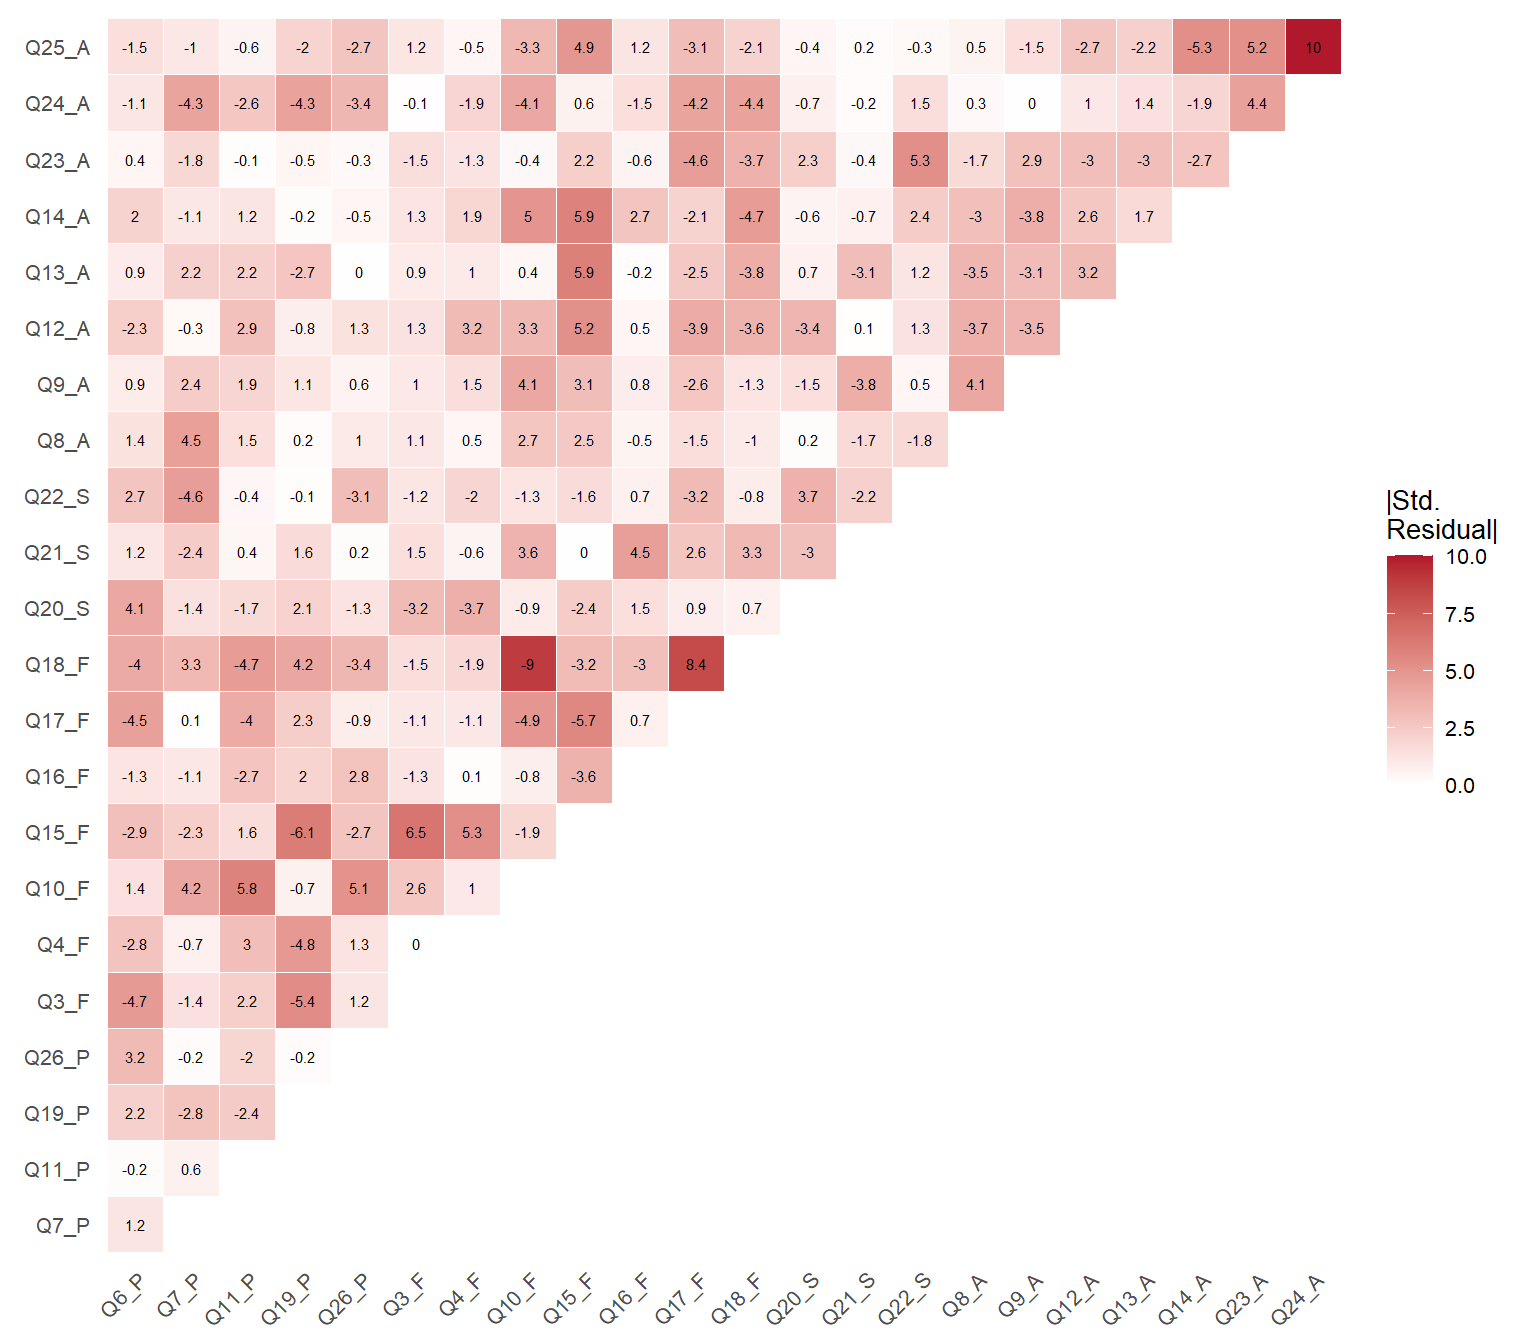

In [ ]:
res_std <- residuals(est_4fb, type = "standardized")$cov
res_std[upper.tri(res_std)] <- NA
diag(res_std) <- NA

res_long <- reshape2::melt(res_std, na.rm = TRUE)
names(res_long) <- c("Item1", "Item2", "value")
res_long$abs_value <- abs(res_long$value)

ggplot(res_long, aes(x = Item2, y = Item1, fill = abs_value)) +
  geom_tile(color = "white") +
  scale_fill_gradient(
    low = "white", high = "#B2182B",
    limit = c(0, max(res_long$abs_value)),
    name = "|Std.\nResidual|"
  ) +
  geom_text(aes(label = round(value, 1)), size = 2) +
  theme_minimal(base_size = 10) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1),
    axis.title = element_blank(),
    panel.grid = element_blank()
  ) +
  coord_fixed()

In [ ]:
knitr::kable(semTools::reliability(est_4fb), digits = 3)

Warning in semTools::reliability(est_4fb): 
The reliability() function was deprecated in 2022 and will cease to be included in future versions of semTools. See help('semTools-deprecated) for details.

It is replaced by the compRelSEM() function, which can estimate alpha and model-based reliability in an even wider variety of models and data types, with greater control in specifying the desired type of reliability coefficient (i.e., more explicitly choosing assumptions). 

The average variance extracted should never have been included because it is not a reliability coefficient. It is now available from the AVE() function.

For constructs with categorical indicators, Zumbo et al.`s (2007) "ordinal alpha" is calculated in addition to the standard alpha, which treats ordinal variables as numeric. See Chalmers (2018) for a critique of "alpha.ord" and the response by Zumbo & Kroc (2019). Likewise, average variance extracted is calculated from polychoric (polyserial) not Pearson correlations.

                psycho   physical   social   environment
  ----------- -------- ---------- -------- -------------
  alpha          0.793      0.823    0.687         0.787
  alpha.ord      0.831      0.863    0.741         0.820
  omega          0.793      0.801    0.708         0.795
  omega2         0.793      0.801    0.708         0.795
  omega3         0.792      0.811    0.725         0.802
  avevar         0.504      0.500    0.524         0.377


Reliability for the Psychological domain remains adequate even after removing Q5, confirming that the item was not essential for capturing the construct. The remaining five items (Q6, Q7, Q11, Q19, Q26) provide a reliable measurement of psychological well-being. All other domains maintain their previous reliability levels.

### Path Diagram

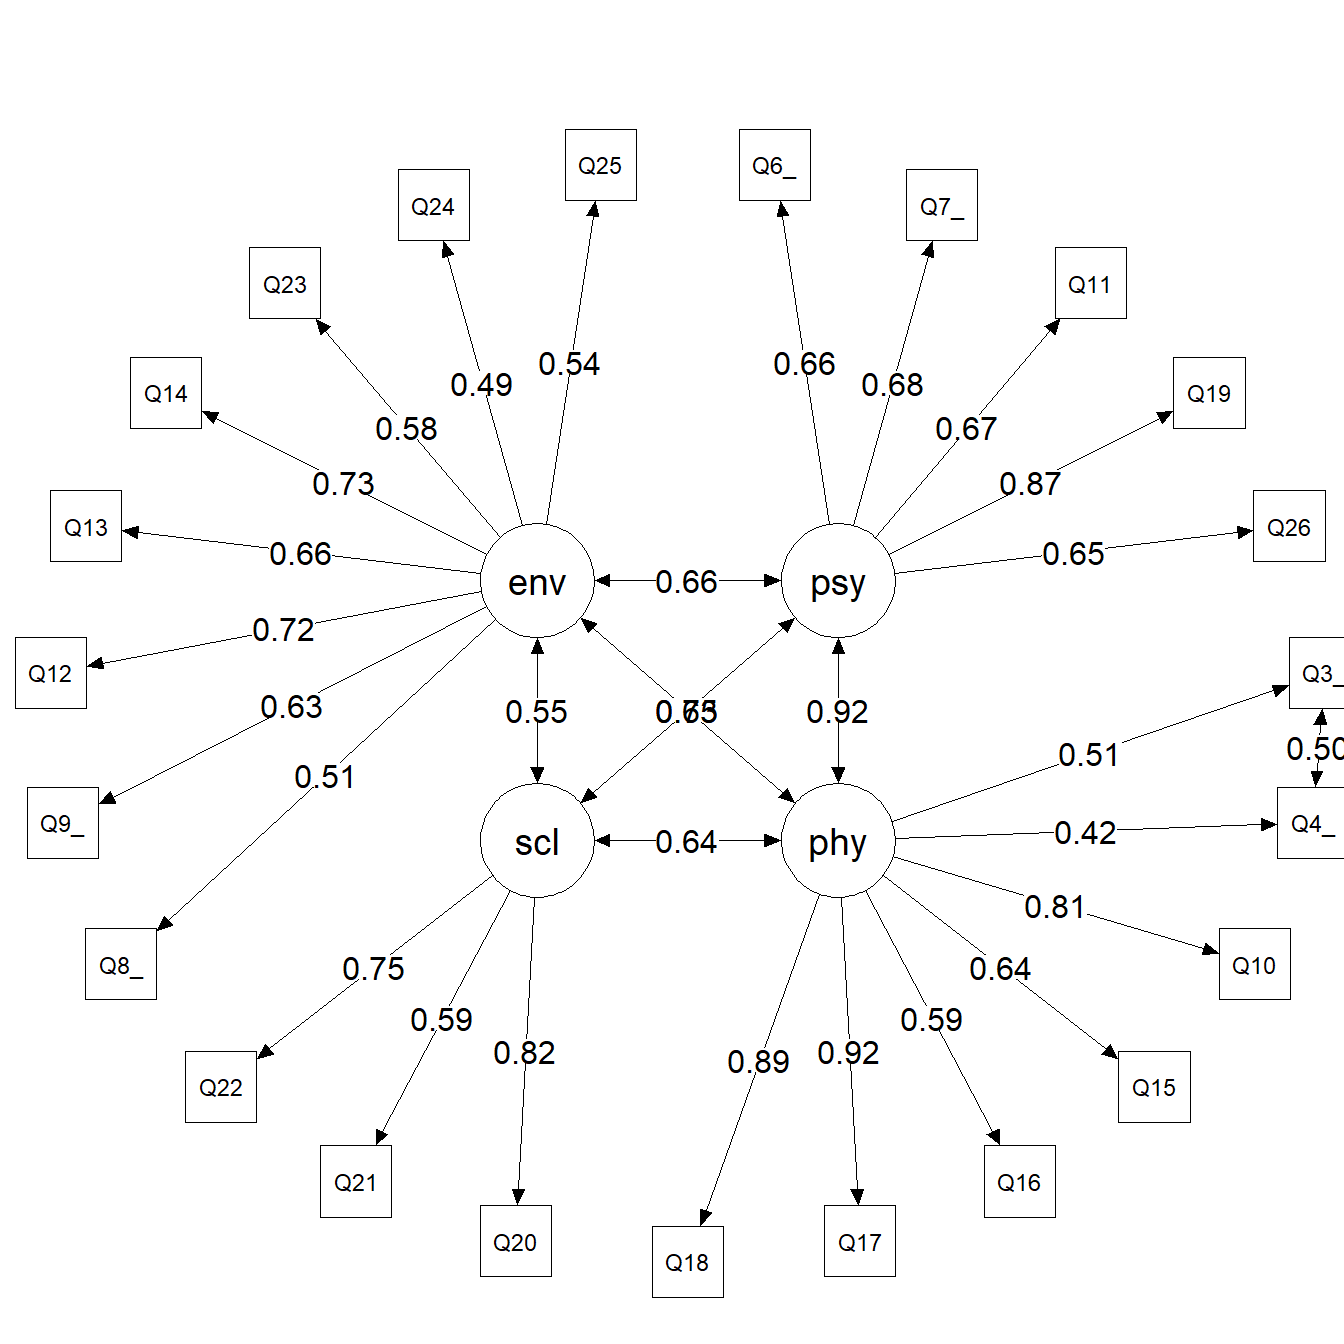

In [ ]:
sem_model_4fb <- semPlot::semPlotModel(est_4fb)

semPlot::semPaths(
  sem_model_4fb,
  what = "std",
  style = "lisrel",
  layout = "circle",
  intercepts = FALSE,
  thresholds = FALSE,
  residuals = FALSE,
  edge.label.cex = 1,
  label.cex = 1,
  weighted = FALSE,
  edge.color = "black",
  mar = c(1.5, 0.8, 3, 0.3)
)

## Model Comparison

We now systematically compare the four models on key fit indices: SRMR, RMSEA (scaled), and CFI (scaled). These three indices capture complementary aspects of model fit — SRMR assesses the average discrepancy in correlations, RMSEA penalizes for model complexity, and CFI compares the model against a baseline independence model.

In [ ]:
fit_4fa    <- fitmeasures(est_4fa,    c("srmr", "rmsea.scaled", "cfi.scaled"))
fit_4f_bi  <- fitmeasures(est_4f_bi,  c("srmr", "rmsea.scaled", "cfi.scaled"))
fit_4f_2or <- fitmeasures(est_4f_2or, c("srmr", "rmsea.scaled", "cfi.scaled"))
fit_4fb    <- fitmeasures(est_4fb,    c("srmr", "rmsea.scaled", "cfi.scaled"))

In [ ]:
comparison_df <- data.frame(
  Model = c("4-Factor (all items)", "Bifactor", "Second-Order", "4-Factor (no Q5)"),
  SRMR = c(fit_4fa["srmr"], fit_4f_bi["srmr"],
           fit_4f_2or["srmr"], fit_4fb["srmr"]),
  RMSEA = c(fit_4fa["rmsea.scaled"], fit_4f_bi["rmsea.scaled"],
            fit_4f_2or["rmsea.scaled"], fit_4fb["rmsea.scaled"]),
  CFI = c(fit_4fa["cfi.scaled"], fit_4f_bi["cfi.scaled"],
          fit_4f_2or["cfi.scaled"], fit_4fb["cfi.scaled"])
)
rownames(comparison_df) <- NULL
knitr::kable(comparison_df, digits = 3)

  Model                     SRMR   RMSEA     CFI
  ---------------------- ------- ------- -------
  4-Factor (all items)     0.057   0.076   0.941
  Bifactor                 0.049   0.068   0.958
  Second-Order             0.054   0.067   0.956
  4-Factor (no Q5)         0.053   0.067   0.956


@tbl-model-comparison shows that the four models exhibit a similar level of misspecification, although the original 4-factor model (with all items) performs slightly worse. The bifactor model shows a marginally better fit, which aligns with findings in the literature — this is likely due to the greater number of free parameters in bifactor structures, which mechanically tend to improve fit indices. As noted by @rogers2024, some authors argue that bifactor models have been used to “salvage” traditional scales that are no longer sustainable under modern estimation and item selection techniques.

> **Model Selection Recommendation**
>
> A known limitation of bifactor models is the assumption that specific factors are uncorrelated — an assumption that frequently does not hold in practice. Additionally, bifactor models can suffer from empirical underidentification and may capitalize on sample-specific variance.
>
> The second-order model also showed convergence problems, requiring the Psychological factor variance to be fixed to zero.
>
> **Based on empirical evidence and practical considerations, the four correlated factor model excluding item Q5 is recommended** for measuring WHOQOL-BREF in this sample. This model:
>
> -   Has acceptable overall and local fit
> -   Avoids the strong orthogonality assumption of bifactor models
> -   Is easier to interpret and communicate to non-technical audiences
> -   Has no convergence issues
> -   Maintains adequate reliability (omega \> .70) across all domains
> -   Is the most parsimonious adequate representation of the data

## Post Hoc Power Analysis

The final step in our CFA workflow is a post hoc power analysis assessing whether the sample size (N = 1047) provides adequate statistical power for parameter estimation and misfit detection. We use Monte Carlo simulation via the `simsem` package: data are repeatedly generated from the fitted model and re-estimated, yielding empirical distributions of parameter estimates and fit indices.

> **Why Post Hoc Power Analysis?**
>
> While *a priori* power analysis is ideal for study planning, *post hoc* simulation-based power analysis provides essential information about: (1) **parameter stability** — whether estimates are consistent across replications; (2) **power to detect non-zero parameters** — whether loadings and correlations are reliably different from zero; (3) **coverage** — whether 95% confidence intervals perform as expected; and (4) **bias** — whether estimates and standard errors are unbiased.

We use the revised four-factor model (without Q5) as both the generating and analysis model. By generating data from the fitted lavaan object, we preserve the ordinal nature of the items and the estimated polychoric structure.

### Define Cutoff Values

In [ ]:
rule_of_thumb <- c(srmr = 0.06, rmsea.scaled = 0.06, cfi.scaled = 0.95)

### Run Simulation

> **Warning**
>
> To reduce computational time, we run 100 replications. For final published results, 1,000–5,000 replications are recommended for stable estimates. More replications yield narrower confidence intervals around power estimates but increase computation time proportionally.

In [ ]:
invisible(capture.output(
  my_modelci <- simsem::sim(
    100,
    n = nrow(df0),
    model = spe_4fb,
    generate = est_4fb,
    lavaanfun = "cfa",
    ordered = TRUE,
    std.lv = TRUE,
    estimator = "WLSMV"
  )
))

The RNGkind() was changed from "Mersenne-Twister" to RNGkind("L'Ecuyer-CMRG") in order to enable the multiple streams in the parallel package.
To set a RNG seed using the previous RNGkind(), you can use
    RNGkind("Mersenne-Twister","Inversion","Rejection")
 or 
    set.seed(seed, kind = "Mersenne-Twister")

Warning in (function (..., deparse.level = 1) : number of columns of result is
not a multiple of vector length (arg 55)

Warning in (function (..., deparse.level = 1) : number of columns of result is
not a multiple of vector length (arg 55)

Warning in (function (..., deparse.level = 1) : number of columns of result is
not a multiple of vector length (arg 55)

Warning in (function (..., deparse.level = 1) : number of columns of result is
not a multiple of vector length (arg 55)

Warning in (function (..., deparse.level = 1) : number of columns of result is
not a multiple of vector length (arg 55)

Warning in (function (..., deparse.level = 1) : number of columns of result is
not a multiple of vector length (arg 55)

### Fit Index Cutoffs

Simulation-based cutoffs at α = .05 provide model-specific and sample-specific alternatives to generic rules of thumb. These cutoffs represent the 95th (or 5th, for CFI) percentile of fit index distributions under the assumption that the model is correctly specified.

In [ ]:
knitr::kable(as.data.frame(t(getCutoff(my_modelci, 0.05,
  usedFit = c("srmr", "rmsea.scaled", "cfi.scaled")))), digits = 4)

                      95%
  -------------- --------
  srmr             0.0238
  rmsea.scaled     0.0122
  cfi.scaled       1.0000


### Power to Detect Misfit

@tbl-power-fit shows the proportion of replications where fit indices exceeded rule-of-thumb cutoffs. Low values (near 0) indicate that the correctly specified model consistently shows good fit — which is the desired result.

In [ ]:
knitr::kable(as.data.frame(t(getPowerFit(my_modelci, cutoff = rule_of_thumb,
  usedFit = c("srmr", "rmsea.scaled", "cfi.scaled")))), digits = 4)

    cfi.scaled   rmsea.scaled   srmr
  ------------ -------------- ------
             1              0      0


> **Interpreting Power to Detect Misfit**
>
> Low proportions in @tbl-power-fit mean that the model fits well in most replications — we have low power to reject it when it is correctly specified, which is exactly what we want. If these proportions were high, it would suggest that even when the model is correct, our sample size causes the fit indices to exceed cutoffs (i.e., the cutoffs are too strict for our model and N).

### Sampling Distributions of Fit Indices

@fig-power-fit shows the empirical distributions of SRMR, RMSEA, and CFI across 100 replications, with rule-of-thumb cutoffs overlaid as vertical lines. The distributions should be concentrated well below (SRMR, RMSEA) or above (CFI) the cutoffs.

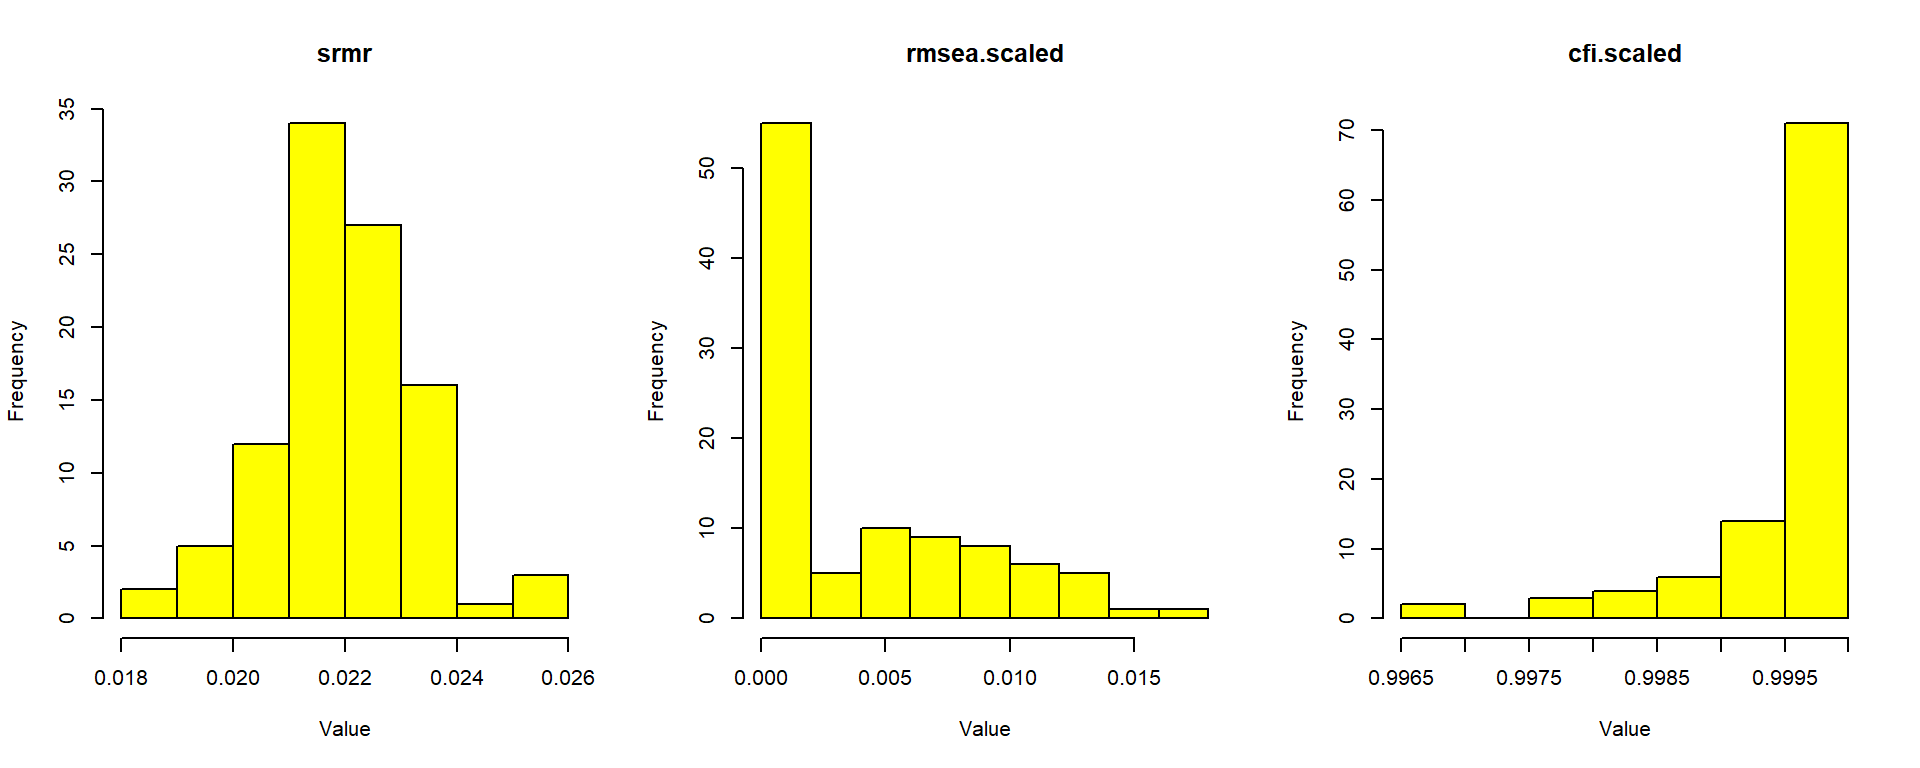

In [ ]:
plotPowerFit(my_modelci, cutoff = rule_of_thumb, logistic = FALSE,
             usedFit = c("srmr", "rmsea.scaled", "cfi.scaled"))

@fig-cutoff-plot presents the same distributions with simulation-based cutoffs at α = .05. The shaded areas represent the rejection regions.

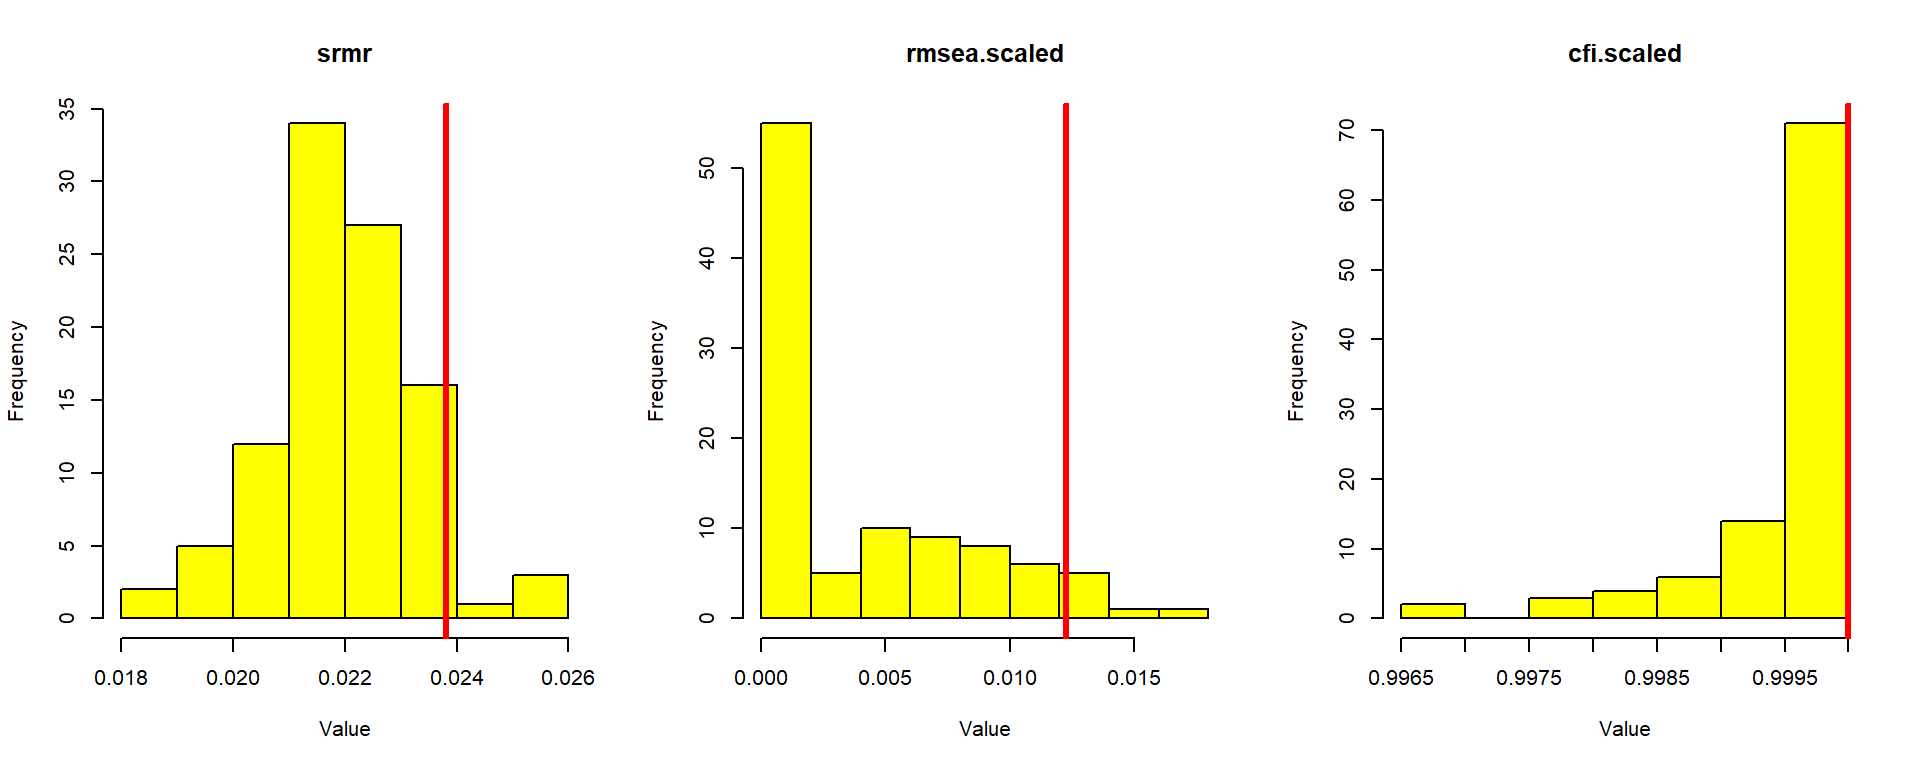

In [ ]:
plotCutoff(my_modelci, 0.05, usedFit = c("srmr", "rmsea.scaled", "cfi.scaled"))

### Detailed Parameter Summary

The comprehensive parameter summary below reports, for each model parameter: coverage (proportion of 95% CIs containing the true value), power (proportion rejecting H₀: parameter = 0), relative bias in estimates, and relative bias in standard errors.

In [ ]:
# Extract simulation results with detail
sim_results <- simsem::summaryParam(my_modelci, detail = TRUE, digits = 3)

# Filter and select columns
sim_table <- sim_results %>%
  tibble::rownames_to_column("Parameter") %>%
  dplyr::filter(!grepl("\\|t", Parameter)) %>%
  dplyr::select(
    "Parameter",
    "Power (Not equal 0)",
    "Coverage",
    "Rel Bias",
    "Rel SE Bias"
  )

# Format with kable
knitr::kable(
  x = sim_table,
  digits = 3,
  align = c("l", "c", "c", "c", "c"),
  col.names = c("Parameter", "Power", "Coverage", "Bias %", "SE Bias %")
)

  Parameter                  Power   Coverage   Bias %   SE Bias %
  ------------------------- ------- ---------- -------- -----------
  psycho=\~Q6_P                1       0.96     0.004      0.060
  psycho=\~Q7_P                1       0.92     0.001     -0.067
  psycho=\~Q11_P               1       0.94     0.004      0.062
  psycho=\~Q19_P               1       0.93     0.005     -0.019
  psycho=\~Q26_P               1       0.96     0.006      0.125
  physical=\~Q3_F              1       0.98     0.002     -0.022
  physical=\~Q4_F              1       0.97     0.000      0.044
  physical=\~Q10_F             1       0.91     0.004     -0.066
  physical=\~Q15_F             1       0.92     -0.001    -0.076
  physical=\~Q16_F             1       0.92     0.003     -0.091
  physical=\~Q17_F             1       0.95     -0.001     0.011
  physical=\~Q18_F             1       0.93     0.001     -0.029
  social=\~Q20_S               1       0.94     0.005      0.029
  social=\~Q21_S               1       0.96     -0.006     0.070
  social=\~Q22_S               1       0.96     0.003     -0.032
  environment=\~Q8_A           1       0.95     -0.006    -0.026
  environment=\~Q9_A           1       0.98     -0.001     0.116
  environment=\~Q12_A          1       0.96     0.003      0.013
  environment=\~Q13_A          1       0.97     0.000     -0.011
  environment=\~Q14_A          1       0.93     -0.003    -0.040
  environment=\~Q23_A          1       0.97     -0.005     0.173
  environment=\~Q24_A          1       0.97     0.001      0.067
  environment=\~Q25_A          1       0.99     0.002      0.082
  Q3_F\~\~Q4_F                 1       0.97     -0.001     0.110
  psycho\~\~physical           1       0.95     -0.004    -0.579
  psycho\~\~social             1       0.95     -0.003    -0.093
  psycho\~\~environment        1       0.94     0.005      0.056
  physical\~\~social           1       0.98     -0.001     0.046
  physical\~\~environment      1       0.88     0.009     -0.121
  social\~\~environment        1       0.92     0.006     -0.124


Only few threshold parameters show power below .80 (see full report), and thresholds are generally not parameters of interest in CFA. All factor loadings and factor correlations are estimated with adequate power, indicating that the sample size is sufficient for reliable parameter estimation.

> **How to Read the Parameter Summary**
>
> Key benchmarks for evaluating simulation quality \[@rogers2024\]:
>
> -   **Power \> .80**: Adequate power to detect non-zero parameters
> -   **Coverage 0.91–0.98**: Confidence intervals perform as expected (neither too liberal nor too conservative)
> -   **Relative Bias \< \|0.10\|**: Parameter estimates are unbiased (within 10% of true values)
> -   **Relative SE Bias \< \|0.10\|**: Standard errors accurately estimate sampling variability
>
> Parameters outside these ranges deserve attention. However, **thresholds are generally not parameters of interest** in CFA. The focus should be on factor loadings, factor correlations, and residual variances.

The simulation results confirm that the sample size of N = 1047 provides adequate power for estimating all parameters of substantive interest. Factor loadings and correlations are estimated with power \> .80, coverage near .95, and negligible bias. This supports the reliability and generalizability of the CFA results presented throughout this tutorial.

## Summary and Conclusions

This supplementary material demonstrated a complete CFA workflow for ordinal data using the WHOQOL-BREF instrument, implementing the best practices described in @rogers2024:

1.  **Data preparation** (@sec-etl): Loaded data directly from Mendeley Data repository, verified structure and descriptive statistics
2.  **Population model** (@sec-popmodel): Defined a teaching example based on @lin2022 with analytically derived residual variances and equidistant thresholds
3.  **Model specification and estimation**: Tested four competing structures:
    -   Original 4-factor model with all 24 items (@sec-4f)
    -   Bifactor model with general QOL factor (@sec-bifactor)
    -   Second-order hierarchical model (@sec-2nd)
    -   Revised 4-factor model excluding problematic item Q5 (@sec-4fb)
4.  **Model evaluation**: Applied DWLS estimation appropriate for ordinal data, examining overall fit (SRMR, RMSEA, CFI), local fit (MI, residuals), reliability (alpha, omega, AVE), and path diagrams
5.  **Model comparison** (@sec-comparison): Systematically compared all models, recommending the revised 4-factor model
6.  **Power analysis** (@sec-power): Assessed statistical adequacy via Monte Carlo simulation

> **Key Findings**
>
> 1.  **Always use appropriate estimators for ordinal data**: DWLS/WLSMV operates on polychoric correlations and does not assume normality of observed variables — using ML with ordinal Likert data leads to biased estimates
> 2.  **Item Q5 is systematically problematic** across multiple model structures and should be excluded
> 3.  **The revised 4-factor correlated model** (without Q5) provides the best balance of fit, interpretability, and statistical properties
> 4.  **Bifactor models improve fit mechanically** but impose strong orthogonality assumptions that rarely hold; they should not be preferred solely on the basis of fit indices
> 5.  **All four domains** show adequate reliability (omega \> .70) in the recommended model
> 6.  **Sample size N = 1047** provides adequate power for all parameters of substantive interest
> 7.  **Examine both overall and local fit** — global indices can mask specific, actionable problems
> 8.  **Modification indices should guide, not dictate**: Only make theoretically justified changes, and be alert to items that appear repeatedly in high MIs

For the full theoretical and methodological framework underlying these analyses, including parallel [JASP implementations](https://github.com/phdpablo/cfa-brm/tree/main/jasp), see @rogers2024, [OSF repository](https://osf.io/cv8wb/overview), and [Github Repository](https://github.com/phdpablo/cfa-brm)

## References